# Customer Churn Analysis: EDA, Survival Analysis & Prediction Modeling

**Team project — merged notebook**

This notebook combines three individually-developed workstreams on the Telco Customer Churn dataset into a single, end-to-end pipeline:

| Section | Original Author(s) | Source Notebook(s) |
|---|---|---|
| 1. Exploratory Data Analysis | Sakshi | `Exploratory_Data_Analysis.ipynb` |
| 2. Customer Survival Analysis | Sakshi | `Customers_Survival_Analysis.ipynb` |
| 3. Churn Prediction Modeling | Sakshi (core RF/XGBoost pipeline + explainability), Zhopu (multi-model benchmarking, LightGBM, SHAP) | `Churn_Prediction_Model.ipynb`, `CustomerChurn.ipynb` |
| 4. Business Application — Risk Segmentation & Retention | Zhopu | `CustomerChurn.ipynb` |
| 5. Export for Tableau / BI | Popu | `churn_analysis_and_modeling.ipynb` |

**Data source:** `Telco_Cusomer_Churn.csv` — update `DATA_PATH` below to point to your local copy.

*A note on merge decisions is included at the end of this cell's neighboring notes throughout the notebook wherever a piece of logic was adapted, reconstructed, or renamed to make everything run in a single, linear pass.*

## 0. Setup — Imports & Data Load

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style('darkgrid')

# --- Survival Analysis ---
from scipy.stats import norm
import statsmodels.api as st
from sklearn.preprocessing import LabelEncoder
from lifelines import KaplanMeierFitter, CoxPHFitter
from lifelines.statistics import multivariate_logrank_test, logrank_test

# --- Modeling ---
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (confusion_matrix, accuracy_score, classification_report,
                              roc_auc_score, roc_curve, precision_score, recall_score,
                              f1_score, precision_recall_curve, average_precision_score)

# --- Explainability ---
import pickle
import joblib

labelencoder = LabelEncoder()

# NOTE: xgboost, lightgbm, eli5, and shap are imported later, right where they are
# first used, since they require a one-time pip install in a fresh environment.

DATA_PATH = "/Users/sakshisingh/Sakshi/Projects/Customer-Survival-Analysis-and-Churn-Prediction/Data/Telco_Cusomer_Churn.csv"   # <-- update this path if needed

df_raw = pd.read_csv(DATA_PATH)
df_raw.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


# 1. Exploratory Data Analysis

In [2]:
df = df_raw.copy()
df.shape

(7043, 21)

In [3]:
df.isna().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

## Analysis

We do not need customer ID in our analysis as it does not help us predict whether the cutomer will churn or not also, it increases the dimensionality.

In [4]:
df.drop(["customerID"], inplace = True, axis = 1)

In [5]:
def stacked_plot(df, group, target):
    """
    Function to generate a stacked plots between two variables
    """
    fig, ax = plt.subplots(figsize = (6,4))
    temp_df = (df.groupby([group, target]).size()/df.groupby(group)[target].count()).reset_index().pivot(columns=target, index=group, values=0)
    temp_df.plot(kind='bar', stacked=True, ax = ax, color = ["green", "darkred"])
    ax.xaxis.set_tick_params(rotation=0)
    ax.set_xlabel(group)
    ax.set_ylabel('Churn Percentage')

### Gender, SeniorCitizen, Partner, Dependents

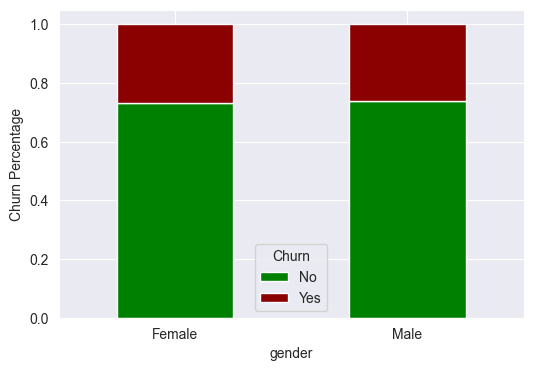

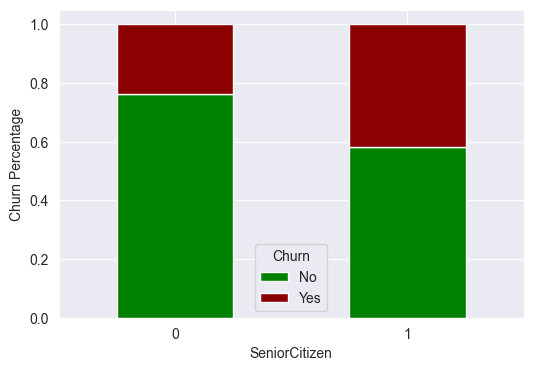

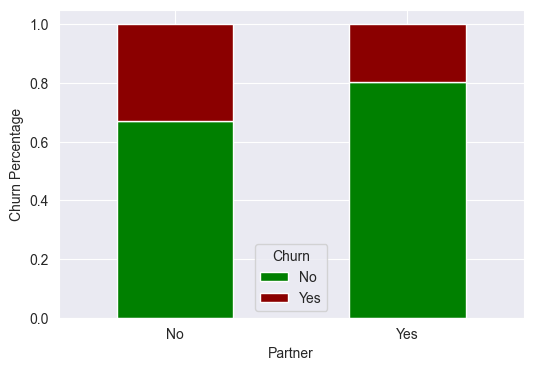

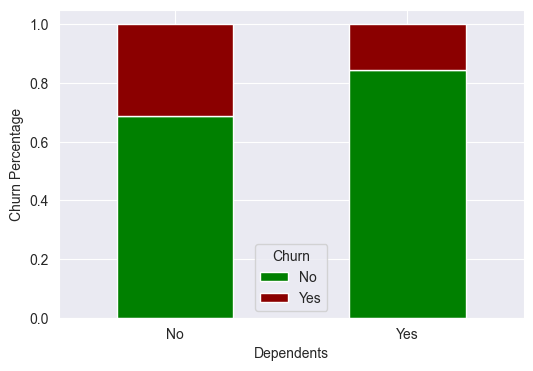

In [6]:
stacked_plot(df, "gender", "Churn")
stacked_plot(df, "SeniorCitizen", "Churn")
stacked_plot(df, "Partner", "Churn")
stacked_plot(df, "Dependents", "Churn")

From above plots, we can say following:
- Gender alone does not help us predict the customer churn.
- If a person is young and has a family, he or she is less likely to stop the service as we can see below. The reason might be the busy life, more money or another factors.

In [7]:
df[(df.SeniorCitizen == 0) & (df.Partner == 'Yes') & (df.Dependents == 'Yes')].Churn.value_counts()

Churn
No     1437
Yes     229
Name: count, dtype: int64

In [8]:
df[(df.SeniorCitizen == 0) & (df.Partner == 'Yes') & (df.Dependents == 'No')].Churn.value_counts()

Churn
No     921
Yes    242
Name: count, dtype: int64

In [9]:
df[(df.SeniorCitizen == 0) & (df.Partner == 'No') & (df.Dependents == 'Yes')].Churn.value_counts()

Churn
No     278
Yes     75
Name: count, dtype: int64

In [10]:
df[(df.SeniorCitizen == 0) & (df.Partner == 'No') & (df.Dependents == 'No')].Churn.value_counts()

Churn
No     1872
Yes     847
Name: count, dtype: int64

### Tenure

In [11]:
df['tenure'].describe()

count    7043.000000
mean       32.371149
std        24.559481
min         0.000000
25%         9.000000
50%        29.000000
75%        55.000000
max        72.000000
Name: tenure, dtype: float64

In [12]:
df['tenure'].value_counts().head(10)

tenure
1     613
72    362
2     238
3     200
4     176
71    170
5     133
7     131
8     123
70    119
Name: count, dtype: int64

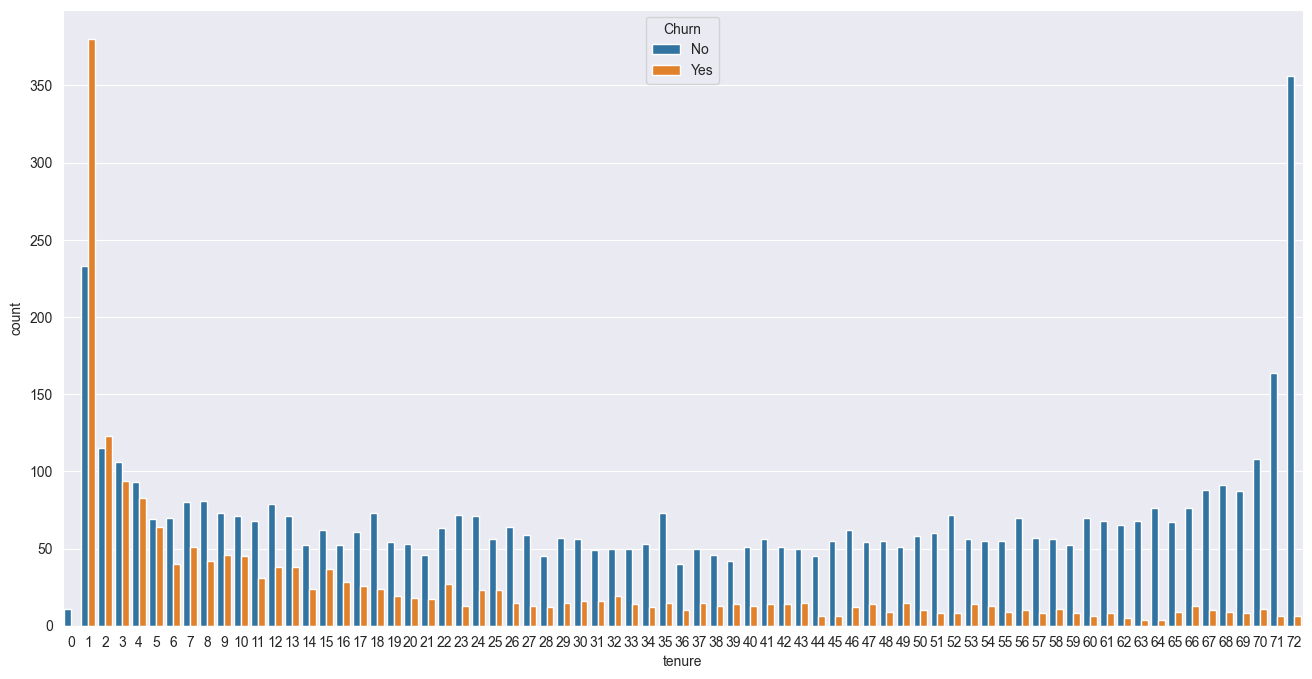

In [13]:
plt.figure(figsize=(16,8))
sns.countplot(x="tenure", hue="Churn", data=df)
plt.show()

As we can see the higher the tenure, the lesser the churn rate. This tells us that the customer becomes loyal with the tenure.

Converting into 5 groups to reduce model complexity.

In [14]:
def tenure(t):
    if t<=12:
        return 1
    elif t>12 and t<=24:
        return 2
    elif t>24 and t<=36:
        return 3
    elif t>36 and t<=48:
        return 4
    elif t>48 and t<=60:
        return 5
    else:
        return 6

df["tenure_group"]=df["tenure"].apply(lambda x: tenure(x))

In [15]:
df["tenure_group"].value_counts()

tenure_group
1    2186
6    1407
2    1024
3     832
5     832
4     762
Name: count, dtype: int64

<Axes: xlabel='tenure_group', ylabel='count'>

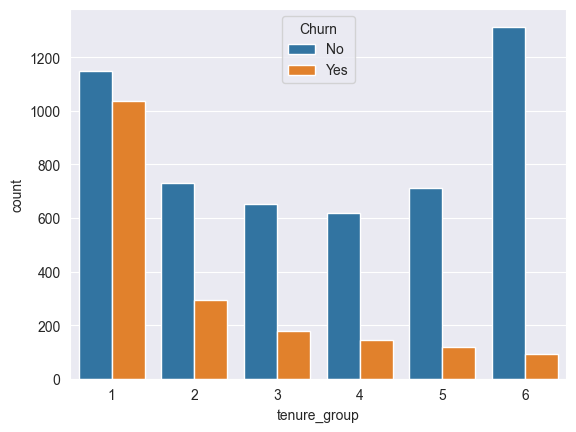

In [16]:
sns.countplot(x="tenure_group", hue="Churn", data=df)

### Phone Service and MultipleLines

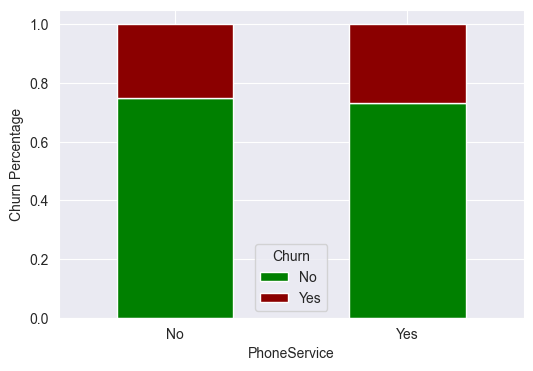

In [17]:
stacked_plot(df, "PhoneService", "Churn")

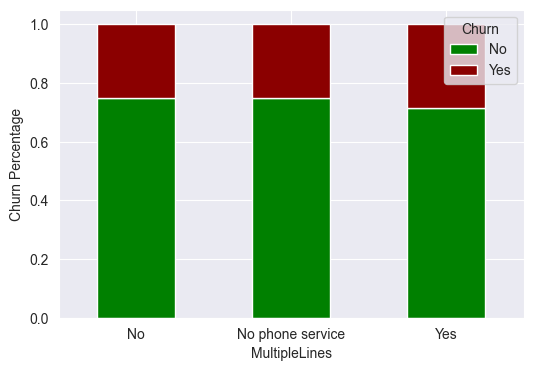

In [18]:
stacked_plot(df, "MultipleLines", "Churn")

As we can see multiplelines and phoneservice do not add value in the model having similar churn rate.

### OnlineSecurity, OnlineBackup, DeviceProtection, TechSupport, StreamingTV, StreamingMovies

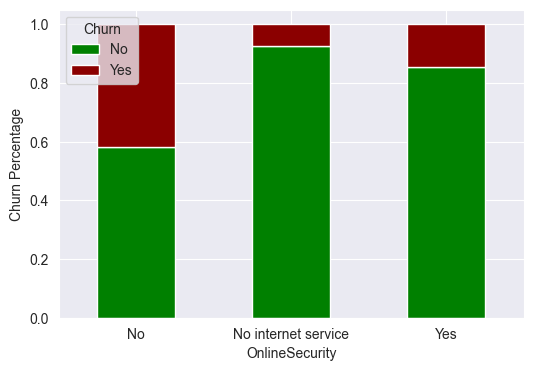

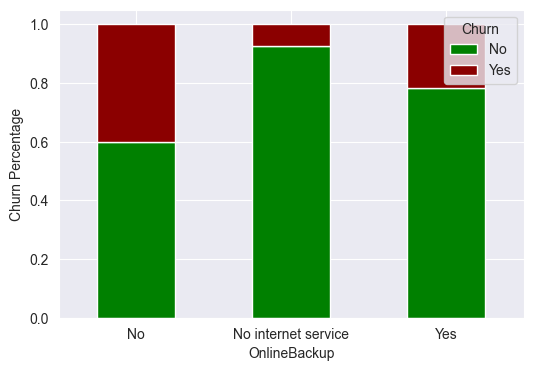

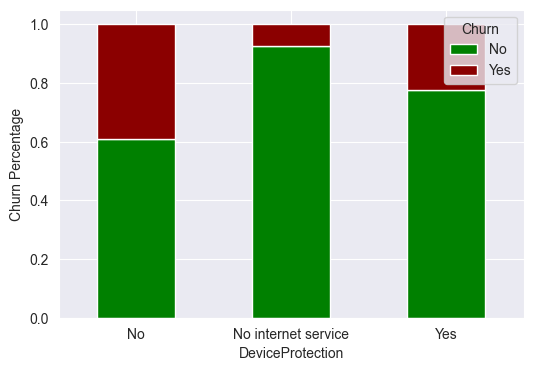

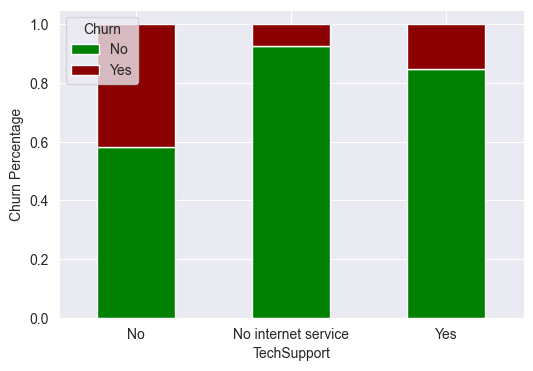

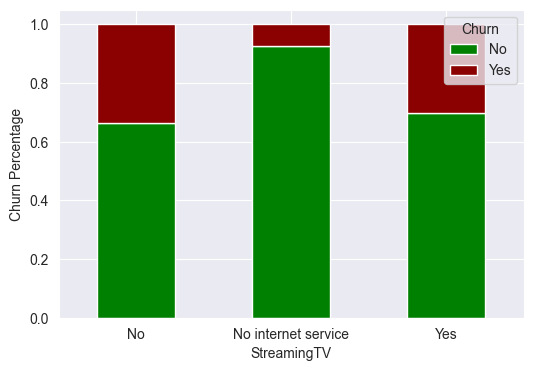

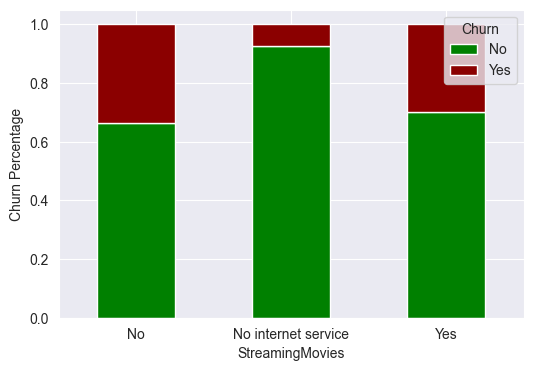

In [19]:
stacked_plot(df, "OnlineSecurity", "Churn")
stacked_plot(df, "OnlineBackup", "Churn")
stacked_plot(df, "DeviceProtection", "Churn")
stacked_plot(df, "TechSupport", "Churn")
stacked_plot(df, "StreamingTV", "Churn")
stacked_plot(df, "StreamingMovies", "Churn")

In all above categories we see consistent results. If a person does not opt for internet service, the customer churning is less. The reason might be the less cost of the service. Also, if they have internet service and does not opt for specific service their probability of churning is high.

/var/folders/41/f97k2tlx2xnftr7h0sg_bp4r0000gn/T/ipykernel_10525/1012111699.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df.tenure[df.OnlineSecurity == "No"], hist_kws=dict(alpha=0.3), label="No")
/var/folders/41/f97k2tlx2xnftr7h0sg_bp4r0000gn/T/ipykernel_10525/1012111699.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974

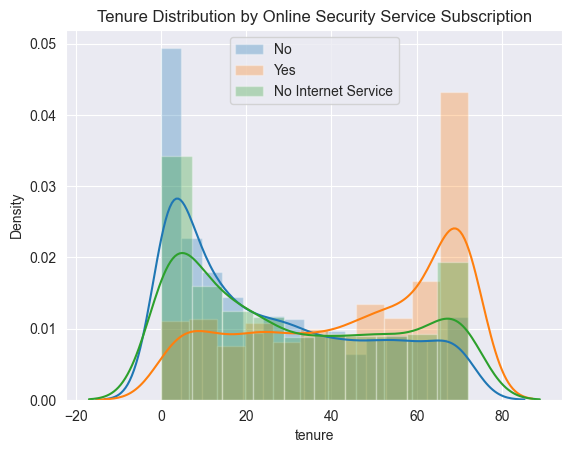

In [20]:
sns.distplot(df.tenure[df.OnlineSecurity == "No"], hist_kws=dict(alpha=0.3), label="No")
sns.distplot(df.tenure[df.OnlineSecurity == "Yes"], hist_kws=dict(alpha=0.3), label="Yes")
sns.distplot(df.tenure[df.OnlineSecurity == "No internet service"], hist_kws=dict(alpha=0.3), label="No Internet Service")
plt.title("Tenure Distribution by Online Security Service Subscription")
plt.legend()
plt.show()

/var/folders/41/f97k2tlx2xnftr7h0sg_bp4r0000gn/T/ipykernel_10525/234875090.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df.tenure[df.StreamingTV == "No"], hist_kws=dict(alpha=0.3), label="No")
/var/folders/41/f97k2tlx2xnftr7h0sg_bp4r0000gn/T/ipykernel_10525/234875090.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad

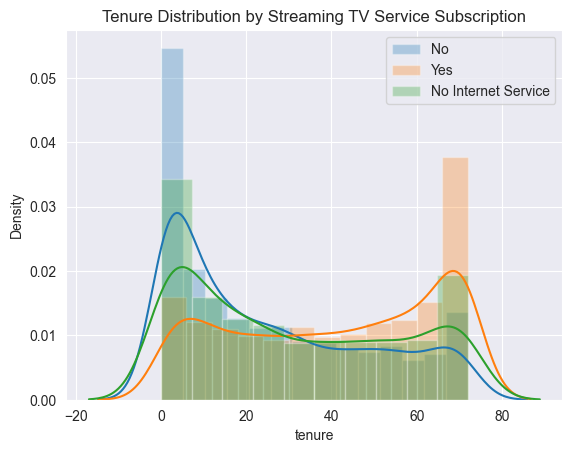

In [21]:
sns.distplot(df.tenure[df.StreamingTV == "No"], hist_kws=dict(alpha=0.3), label="No")
sns.distplot(df.tenure[df.StreamingTV == "Yes"], hist_kws=dict(alpha=0.3), label="Yes")
sns.distplot(df.tenure[df.StreamingTV == "No internet service"], hist_kws=dict(alpha=0.3), label="No Internet Service")
plt.title("Tenure Distribution by Streaming TV Service Subscription")
plt.legend()
plt.show()

/var/folders/41/f97k2tlx2xnftr7h0sg_bp4r0000gn/T/ipykernel_10525/2559911927.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df.tenure[df.StreamingMovies == "No"], hist_kws=dict(alpha=0.3), label="No")
/var/folders/41/f97k2tlx2xnftr7h0sg_bp4r0000gn/T/ipykernel_10525/2559911927.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed297

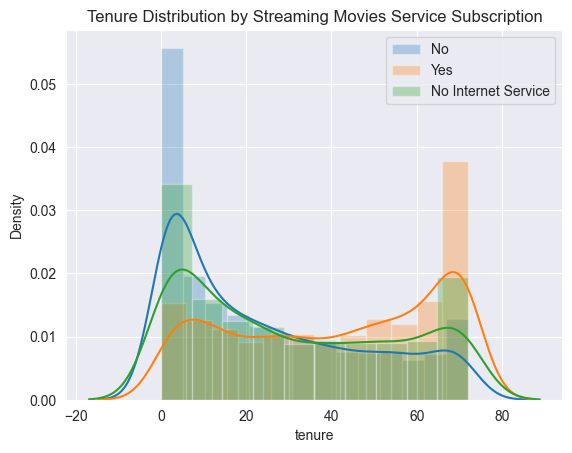

In [22]:
sns.distplot(df.tenure[df.StreamingMovies == "No"], hist_kws=dict(alpha=0.3), label="No")
sns.distplot(df.tenure[df.StreamingMovies == "Yes"], hist_kws=dict(alpha=0.3), label="Yes")
sns.distplot(df.tenure[df.StreamingMovies == "No internet service"], hist_kws=dict(alpha=0.3), label="No Internet Service")
plt.title("Tenure Distribution by Streaming Movies Service Subscription")
plt.legend()
plt.show()

As we can see, when the customers are new they do not opt for various services and their churning rate is very high.

### InternetService

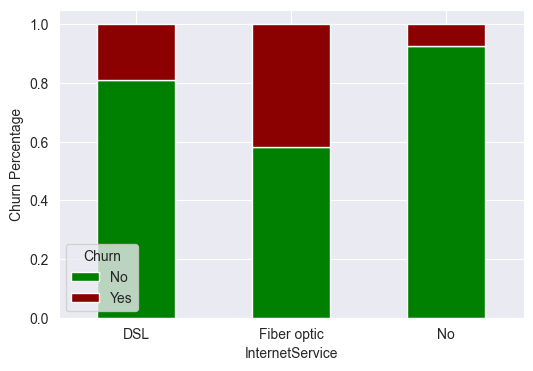

In [23]:
stacked_plot(df, "InternetService", "Churn")

When the internet service is Fiber Optic, the churn rate is very high. Fiber Optics provides highr speed compared to DSL. The reason might be the higher cost of fiber optics.

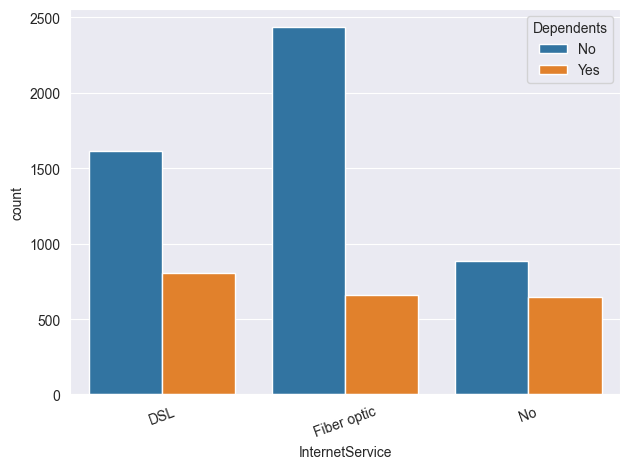

In [24]:
sns.countplot(data=df, x="InternetService", hue="Dependents")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

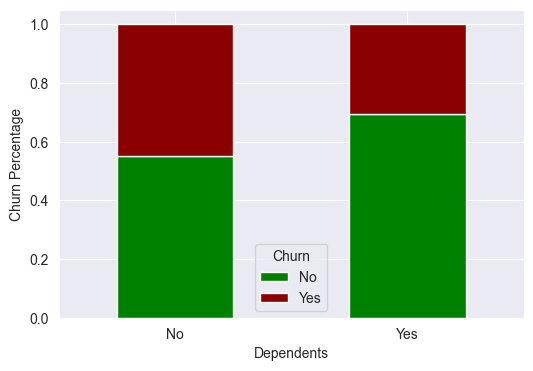

In [25]:
stacked_plot(df[df.InternetService == "Fiber optic"], "Dependents", "Churn")

Mostly people without dependents go for fiber optic option as Internnet Service and their churning percentage is high.

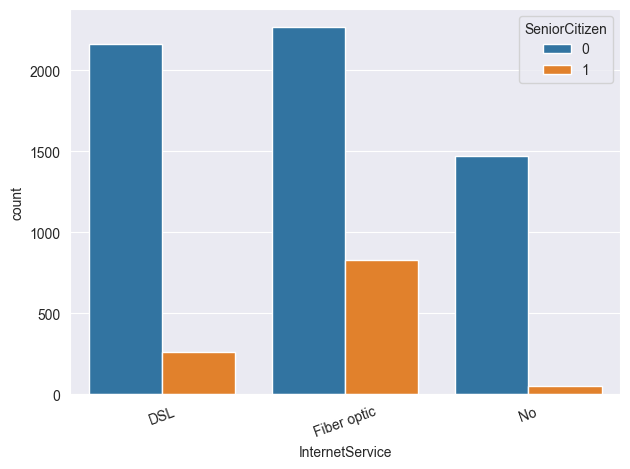

In [26]:
sns.countplot(data=df, x="InternetService", hue="SeniorCitizen")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

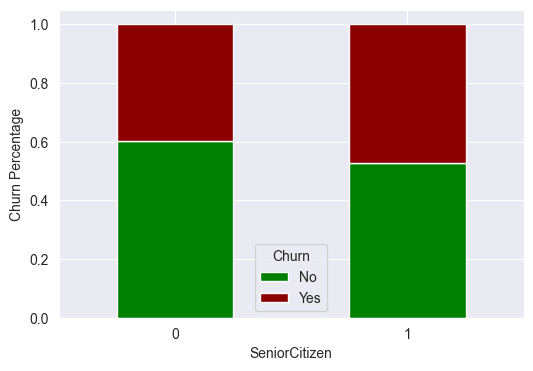

In [27]:
stacked_plot(df[df.InternetService == "Fiber optic"], "SeniorCitizen", "Churn")

As we can see, Partner and Senior Citizen do not tell us anything about why fiber optics have higher churning rate.

/var/folders/41/f97k2tlx2xnftr7h0sg_bp4r0000gn/T/ipykernel_10525/131648593.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df.tenure[df.InternetService == "No"], hist_kws=dict(alpha=0.3), label="No")
/var/folders/41/f97k2tlx2xnftr7h0sg_bp4r0000gn/T/ipykernel_10525/131648593.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed29744

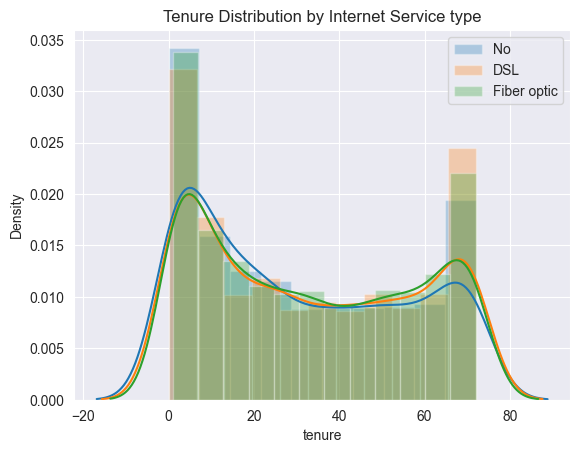

In [28]:
sns.distplot(df.tenure[df.InternetService == "No"], hist_kws=dict(alpha=0.3), label="No")
sns.distplot(df.tenure[df.InternetService == "DSL"], hist_kws=dict(alpha=0.3), label="DSL")
sns.distplot(df.tenure[df.InternetService == "Fiber optic"], hist_kws=dict(alpha=0.3), label="Fiber optic")
plt.title("Tenure Distribution by Internet Service type")
plt.legend()
plt.show()

Also, the tenure distribution of customers with different internet service is similar.

In [29]:
df[df.InternetService == 'No'].head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,...,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,tenure_group
11,Male,0,No,No,16,Yes,No,No,No internet service,No internet service,...,No internet service,No internet service,No internet service,Two year,No,Credit card (automatic),18.95,326.8,No,2
16,Female,0,No,No,52,Yes,No,No,No internet service,No internet service,...,No internet service,No internet service,No internet service,One year,No,Mailed check,20.65,1022.95,No,5
21,Male,0,Yes,No,12,Yes,No,No,No internet service,No internet service,...,No internet service,No internet service,No internet service,One year,No,Bank transfer (automatic),19.80,202.25,No,1
22,Male,0,No,No,1,Yes,No,No,No internet service,No internet service,...,No internet service,No internet service,No internet service,Month-to-month,No,Mailed check,20.15,20.15,Yes,1
33,Male,0,No,No,1,Yes,No,No,No internet service,No internet service,...,No internet service,No internet service,No internet service,Month-to-month,No,Bank transfer (automatic),20.20,20.2,No,1


In [30]:
df[df.InternetService == 'No'].OnlineSecurity.value_counts()

OnlineSecurity
No internet service    1526
Name: count, dtype: int64

In [31]:
df[df.InternetService == 'No'].OnlineBackup.value_counts()

OnlineBackup
No internet service    1526
Name: count, dtype: int64

In [32]:
df[df.InternetService == 'No'].DeviceProtection.value_counts()

DeviceProtection
No internet service    1526
Name: count, dtype: int64

In [33]:
df[df.InternetService == 'No'].TechSupport.value_counts()

TechSupport
No internet service    1526
Name: count, dtype: int64

In [34]:
df[df.InternetService == 'No'].StreamingMovies.value_counts()

StreamingMovies
No internet service    1526
Name: count, dtype: int64

In [35]:
df[df.InternetService == 'No'].StreamingTV.value_counts()

StreamingTV
No internet service    1526
Name: count, dtype: int64

We need to encode these variables to remove dependancy in the model.

### Contract

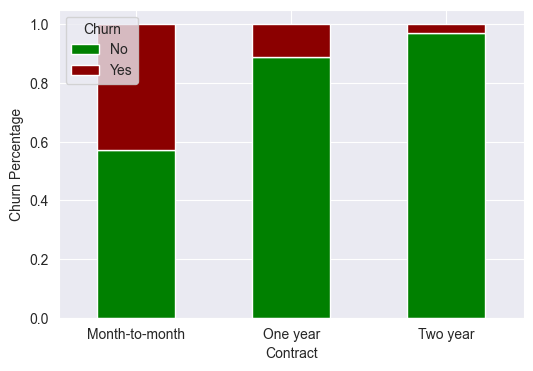

In [36]:
stacked_plot(df, "Contract", "Churn")

In the case of Month-to-month contract Churn rate is very high. There is also a posibility of having customers in the dataframe who are still in their two-year or one-year contract plan.

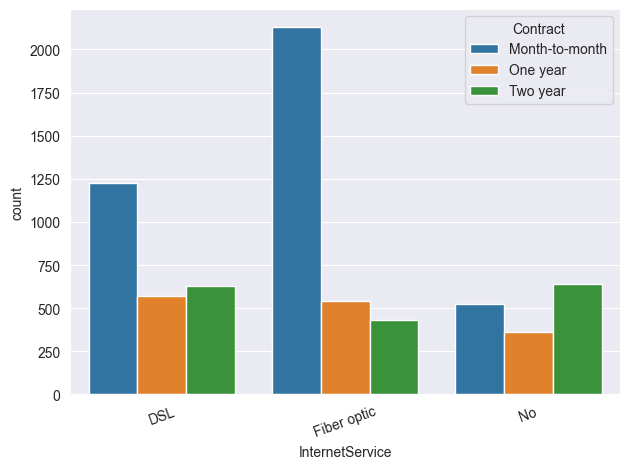

In [37]:
sns.countplot(data=df, x="InternetService", hue="Contract")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

Many of the people of who opt for month-to-month Contract choose Fiber optic as Internet service and this is the reason for higher churn rate for fiber optic Internet service type.

### PaymentMethod

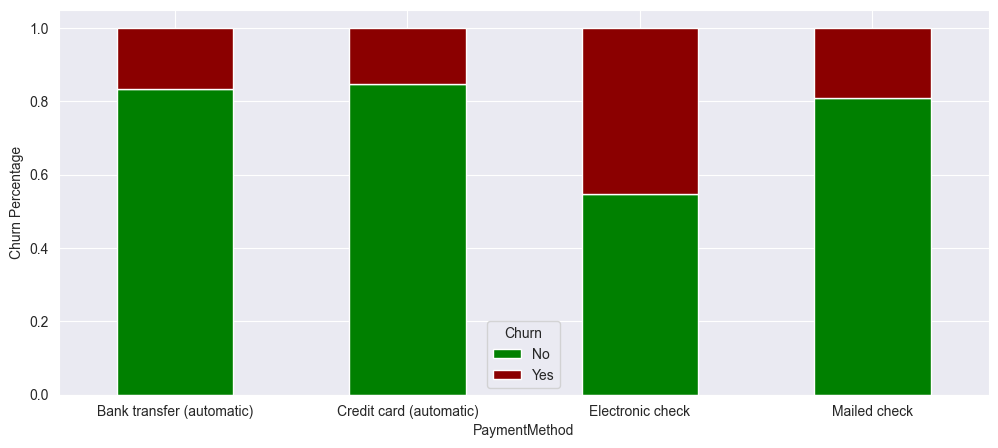

In [38]:
group = "PaymentMethod"
target = "Churn"
fig, ax = plt.subplots(figsize = (12,5))
temp_df = (df.groupby([group, target]).size()/df.groupby(group)[target].count()).reset_index().pivot(columns=target, index=group, values=0)
temp_df.plot(kind='bar', stacked=True, ax = ax, color = ["green", "darkred"])
ax.xaxis.set_tick_params(rotation=0)
ax.set_xlabel(group)
ax.set_ylabel('Churn Percentage');

In the case of Electronic check, churn is very high.

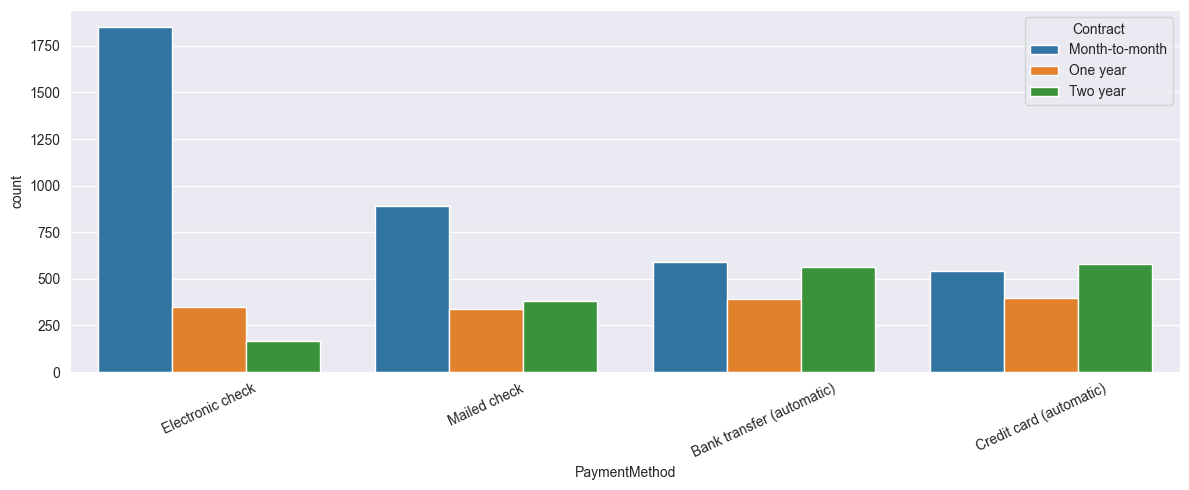

In [39]:
fig, ax = plt.subplots(figsize=(12, 5))
sns.countplot(data=df, x="PaymentMethod", hue="Contract", ax=ax)
ax.tick_params(axis="x", rotation=25)
plt.tight_layout()
plt.show()

People having month-to-month contract prefer paying by Electronic Check mostly or mailed check. The reason might be short subscription cancellation process compared to automatic payment.

### PaperlessBilling

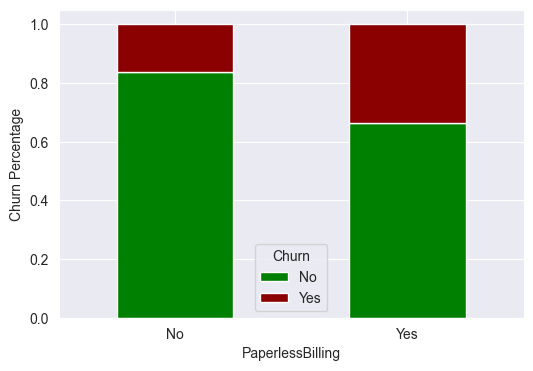

In [40]:
stacked_plot(df, "PaperlessBilling", "Churn")

### TotalCharges

In [41]:
df.TotalCharges.describe()

count     7043
unique    6531
top           
freq        11
Name: TotalCharges, dtype: object

In [42]:
df['TotalCharges'] = df["TotalCharges"].replace(" ",np.nan)
df['TotalCharges'].isna().sum()

np.int64(11)

In [43]:
df[df["TotalCharges"].isnull()]

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,...,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,tenure_group
488,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,No,...,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,NaN,No,1
753,Male,0,No,Yes,0,Yes,No,No,No internet service,No internet service,...,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,NaN,No,1
936,Female,0,Yes,Yes,0,Yes,No,DSL,Yes,Yes,...,No,Yes,Yes,Two year,No,Mailed check,80.85,NaN,No,1
1082,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,No internet service,...,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,NaN,No,1
1340,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,Yes,...,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,NaN,No,1
3331,Male,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,...,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.85,NaN,No,1
3826,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,No internet service,...,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,NaN,No,1
4380,Female,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,...,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,NaN,No,1
5218,Male,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,...,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,NaN,No,1
6670,Female,0,Yes,Yes,0,Yes,Yes,DSL,No,Yes,...,Yes,Yes,No,Two year,No,Mailed check,73.35,NaN,No,1


All the customers having tenure = 0 have null total charges which means that these customers recently joined and we can fill those missing values as 0.

In [44]:
df.loc[df["TotalCharges"].isnull(), 'TotalCharges'] = 0
df.isnull().any().any()

np.False_

In [45]:
df['TotalCharges'] = df["TotalCharges"].astype(float)

Churn = df[df.Churn=="Yes"]
Not_Churn = df[df.Churn=="No"]

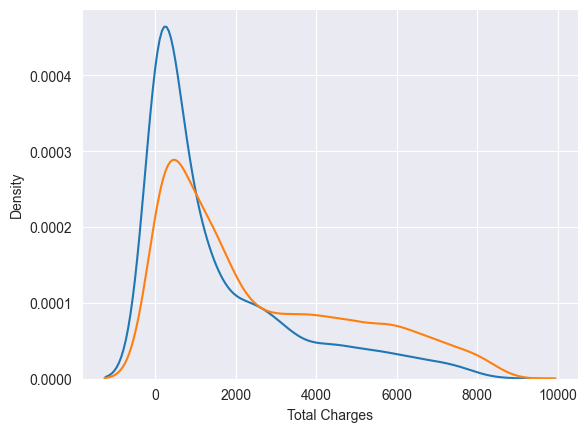

In [46]:
fig, ax = plt.subplots()
sns.kdeplot(Churn["TotalCharges"],label = "Churn", ax= ax)
sns.kdeplot(Not_Churn["TotalCharges"], label = "Not Churn", ax=ax)
ax.set_xlabel("Total Charges");

The density of total charges for churning customers are high around 0. As many customers cancel the subsription in 1-2 months.

### Monthly Charges

In [47]:
df.MonthlyCharges.describe()

count    7043.000000
mean       64.761692
std        30.090047
min        18.250000
25%        35.500000
50%        70.350000
75%        89.850000
max       118.750000
Name: MonthlyCharges, dtype: float64

In [48]:
df.MonthlyCharges.isna().sum()

np.int64(0)

<Axes: xlabel='MonthlyCharges', ylabel='Density'>

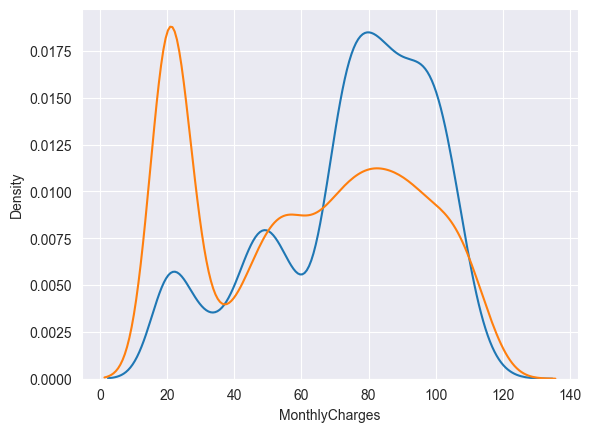

In [49]:
sns.kdeplot(Churn["MonthlyCharges"], label = "Churn")
sns.kdeplot(Not_Churn["MonthlyCharges"], label = "Not Churn")

The customers paying high monthly fees churn more.

Let's see the correlation of total charges and (monthly charges x tenure) to check if we have redundant information.

In [50]:
np.corrcoef(df.TotalCharges, df.MonthlyCharges*df.tenure)

array([[1.        , 0.99956055],
       [0.99956055, 1.        ]])

Let's keep total charges as it shows the interaction between tenure and monthly charges

## Function to prepare data for model building based on EDA

This function encodes every finding from the EDA above into a single reusable pipeline step. It is reused unchanged in the Survival Analysis and Prediction Modeling sections below so the whole notebook stays consistent.

In [51]:
def datapreparation(filepath):

    df = pd.read_csv(filepath)
    df.drop(["customerID"], inplace = True, axis = 1)

    df.TotalCharges = df.TotalCharges.replace(" ",np.nan)
    df.TotalCharges.fillna(0, inplace = True)
    df.TotalCharges = df.TotalCharges.astype(float)

    cols1 = ['Partner', 'Dependents', 'PaperlessBilling', 'Churn', 'PhoneService']
    for col in cols1:
        df[col] = df[col].apply(lambda x: 0 if x == "No" else 1)

    df.gender = df.gender.apply(lambda x: 0 if x == "Male" else 1)
    df.MultipleLines = df.MultipleLines.map({'No phone service': 0, 'No': 0, 'Yes': 1})

    cols2 = ['OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies']
    for col in cols2:
        df[col] = df[col].map({'No internet service': 0, 'No': 0, 'Yes': 1})

    df = pd.get_dummies(df, columns=['InternetService', 'Contract', 'PaymentMethod'], drop_first=True)

    return df

In [52]:
new_df = datapreparation(DATA_PATH)
new_df.head(10)

/var/folders/41/f97k2tlx2xnftr7h0sg_bp4r0000gn/T/ipykernel_10525/52434926.py:7: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df.TotalCharges.fillna(0, inplace = True)


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,OnlineSecurity,OnlineBackup,DeviceProtection,...,MonthlyCharges,TotalCharges,Churn,InternetService_Fiber optic,InternetService_No,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,1,0,1,0,1,0,0,0,1,0,...,29.85,29.85,0,False,False,False,False,False,True,False
1,0,0,0,0,34,1,0,1,0,1,...,56.95,1889.50,0,False,False,True,False,False,False,True
2,0,0,0,0,2,1,0,1,1,0,...,53.85,108.15,1,False,False,False,False,False,False,True
3,0,0,0,0,45,0,0,1,0,1,...,42.30,1840.75,0,False,False,True,False,False,False,False
4,1,0,0,0,2,1,0,0,0,0,...,70.70,151.65,1,True,False,False,False,False,True,False
5,1,0,0,0,8,1,1,0,0,1,...,99.65,820.50,1,True,False,False,False,False,True,False
6,0,0,0,1,22,1,1,0,1,0,...,89.10,1949.40,0,True,False,False,False,True,False,False
7,1,0,0,0,10,0,0,1,0,0,...,29.75,301.90,0,False,False,False,False,False,False,True
8,1,0,1,0,28,1,1,0,0,1,...,104.80,3046.05,1,True,False,False,False,False,True,False
9,0,0,0,1,62,1,0,1,1,0,...,56.15,3487.95,0,False,False,True,False,False,False,False


# 2. Customer Survival Analysis

## Theory

If time to event has the probability density function $f(t)$ and cumulative distribution function $F(t)$, then the probability of surviving at least to time $t$ is: $Pr(T>t)=S(t)=1-F(t)$.

Cumulative hazard at time t is defined as $H(t)=-ln(S(t))$ and instantaneous hazard at time $t$ is $h(t)=\frac{dH(t)}{dt}$. The instantateous hazard can also be written as $h(t)=\frac{f(t)}{S(t)}$

The likelihood function for survival analysis is described as:

$$ l(\beta) = \prod_{n=1}^{n} h(t_{i})^{d_{i}} S(t_{i}) $$
where $d_i$ is the censoring variable that equals to 1 if the event is observed for individual $i$ and 0 if the event is not observed (censored) for individual $i$, $h(t_i)$ is the hazard for individual $i$ at time $t$, $H(t_i)$ is the cumulative hazard for individual $i$ at time $t$, and $S(t_i)$ is the survival probability for individual $i$ at time $t$. Note that when $d_i=0$, the contribution of the $i$'th individual to the likelihood function is just its survival probability until time $t$: S(t). If the individual has the event, the contribution to the likelihood function is given by the density function $f(t)=h(t)S(t)$.

The log of likelihood is:

$$ logl(\beta) = \sum_{i=1}^n d_i log(h(t_i)) - H(t_i) $$
where $log$ is the natural logarithm.

## Data Preparation

*(Libraries for survival analysis — `lifelines`, `statsmodels`, `LabelEncoder` — were already imported in the Setup cell at the top of the notebook.)*

In [53]:
df_surv = df_raw.copy()
df_surv.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [54]:
df_surv.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


Here, Churn is an event which indicates whether customer exited or not. Tenure shows how long customer remained in our service. Both of these variables are very important for customer survival analysis.

In [55]:
df_surv.Churn = labelencoder.fit_transform(df_surv.Churn)
df_surv.Churn.value_counts()

Churn
0    5174
1    1869
Name: count, dtype: int64

In [56]:
eventvar = df_surv['Churn']
timevar = df_surv['tenure']

For the analysis, I will need to create dummy variables for all categorical variables.

In [57]:
categorical = ['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines',
       'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
       'PaperlessBilling', 'PaymentMethod']

survivaldata = pd.get_dummies(df_surv, columns = categorical, drop_first= True)
survivaldata.head()

,customerID,tenure,MonthlyCharges,TotalCharges,Churn,gender_Male,SeniorCitizen_1,Partner_Yes,Dependents_Yes,PhoneService_Yes,...,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,7590-VHVEG,1,29.85,29.85,0,False,False,True,False,False,...,False,False,False,False,False,False,True,False,True,False
1,5575-GNVDE,34,56.95,1889.5,0,True,False,False,False,True,...,False,False,False,False,True,False,False,False,False,True
2,3668-QPYBK,2,53.85,108.15,1,True,False,False,False,True,...,False,False,False,False,False,False,True,False,False,True
3,7795-CFOCW,45,42.30,1840.75,0,True,False,False,False,False,...,False,False,False,False,True,False,False,False,False,False
4,9237-HQITU,2,70.70,151.65,1,False,False,False,False,True,...,False,False,False,False,False,False,True,False,True,False


We need to drop variables such as customerID, tenure, Churn as they are not needed in survival data. Also, we need to add constant for survival analysis.

In [58]:
survivaldata.drop(['customerID', 'tenure', 'Churn'], axis = 1, inplace= True)
survivaldata = st.add_constant(survivaldata, prepend=False)
survivaldata.head()

,MonthlyCharges,TotalCharges,gender_Male,SeniorCitizen_1,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,MultipleLines_Yes,InternetService_Fiber optic,...,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,const
0,29.85,29.85,False,False,True,False,False,True,False,False,...,False,False,False,False,False,True,False,True,False,1.0
1,56.95,1889.5,True,False,False,False,True,False,False,False,...,False,False,False,True,False,False,False,False,True,1.0
2,53.85,108.15,True,False,False,False,True,False,False,False,...,False,False,False,False,False,True,False,False,True,1.0
3,42.30,1840.75,True,False,False,False,False,True,False,False,...,False,False,False,True,False,False,False,False,False,1.0
4,70.70,151.65,False,False,False,False,True,False,False,True,...,False,False,False,False,False,True,False,True,False,1.0


## Survival Analysis

### Kaplan-Meier Curve

The Kaplan-Meier method calculates the probability of survival at time 𝑡  as:

$$ S(t) = \prod_{i=1}^{t-1} (1 - \frac{d_i}{n_i}) $$

where,
- 𝑆(𝑡) is the probability of survival until time 𝑡,
- $𝑑_𝑖$  is the number of units that experienced the event at time 𝑡,
- $𝑛_𝑖$  is the number of units at risk of experiencing the event at time 𝑡.

$𝑛_𝑖$ decreases with time, as units experience the event or are censored. $\frac{d_i}{n_i}$ is the probability of experiencing the event at time 𝑖 and $(1− \frac{d_i}{n_i})$ is the probability of surviving at time 𝑖.

Note that this method does not use any parameters, it only depends on the data on time and censoring.

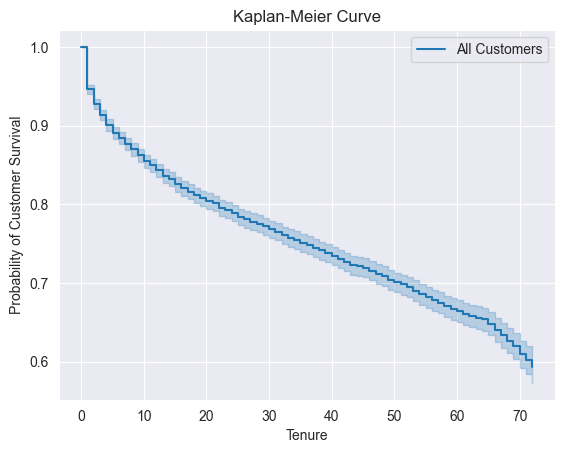

In [59]:
#Create a KaplanMeier object, imported from lifelines
kmf = KaplanMeierFitter()
#Calculate the K-M curve for all groups
kmf.fit(timevar,event_observed = eventvar,label = "All Customers")
#Plot the curve and assign labels
kmf.plot()
plt.ylabel('Probability of Customer Survival')
plt.xlabel('Tenure')
plt.title('Kaplan-Meier Curve');

As we can see, there is a sudden drop in the starting which says that after one tenure only customers starts churning rapidly and after that churning rate decreases. To deal with that we can consider giving more discounts on long-term plans and make more customers to subscribe for long term plans.

### Log-Rank Test

We can use non-parametric method log-rank test to compare survival curves between different groups. The log-rank test assumes that the hazards of the groups are proportional. Under the null hypothesis, the probability of event across the groups is the same for all time points.

To test the null hypothesis, the log-rank test calculates the difference between the observed number of events and the number of events expected in each group proportional to the size of the groups at each time point an event is observed. The log-rank test statistic for group $j$ $(k_{j})$ follows a $\chi^2$ distribution and is calculated as:

$$k_{j} = \frac{(O_{j}-E_{j})^{2}}{var(O_{j}-E_{j})}$$

$O_{j}-E_{j}$ is calculated as:

$$O_{j}-E_{j} = \sum_{i}(o_{ij}-e_{ij})$$

and $var(O_{j}-E_{j})$ is:

$$var(O_{j}-E_{j}) = o_{i}\frac{n_{ij}}{n_{i}}\Big(1-\frac{n_{ij}}{n_{i}}\Big)\frac{(n_{i}-o_{i})}{(n_{i}-1)}$$

$o_{ij}$ is the observed number of events in group $j$ at time $i$ and $e_{ij}$ is the expected number of events in group $j$ at time $i$, which is calculated as $e_{ij} = \frac{n_{ij}}{n_i}{o_{i}}$. Note that $\frac{n_{ij}}{n_i}$ is the proportion of units in group $j$ at risk of event at time $i$ ($n_{ij}$) to the number of units in all groups at risk of event at time $i$ ($n_{i}$) and ${o_{i}}$ is the observed number of events in all groups at time $i$.

When comparing multiple groups, we first calculate the pairwise log-rank test scores between each of the $k-1$ groups, and write them as a vector of log-rank statistics, $\bf{Z}$ which has $k - 1$ elements. We can leave any of one of the statistics out, because the $k$ covariances are linearly dependent on each other (the sum of log-rank statistics is 0, $\sum k_{j}=0$.

The test statistic for the hypothesis that there is no difference in survival times of $k$ groups is calculated as:

$$logrankstatistic = \bf{Z} {\sum}^{-1} \bf{Z}'$$

which has a $\chi^2$ distribution, where ${\sum}^{-1}$ is the inverse of the $k-1$ by $k-1$ variance-covariance matrix of $\bf{Z}$, which has variance of $k_{j}$ on its diagonal elements and $covar(k_{jg})$ on its off-diagonal elements.

The variance of observed number of events in group $j$ is calculated as $var(O_{j}-E_{j})$ as demonstrated above. The covariance between the observed number of events in group $j$ and $g$ is calculated as:

$$covar(k_{jg})=o_{i}\frac{(n_{ij}n_{ig})}{(n_{i}n_{i})}\frac{(n_{i}-o_{i})}{(n_{i}-1)}$$

Note that rejecting the null hypothesis means that the survival times of groups do not come from the same distribution, it does not specify which group's survival time is different. The following plots and test statistics compare the groups in the dataset in terms of the different explanatory variables. Astatistically significant log-rank test statistic indicates that we can reject the null hypothesis that time to survival in all groups come from the same distribution.

### Gender

<lifelines.StatisticalResult: logrank_test>
               t_0 = -1
 null_distribution = chi squared
degrees_of_freedom = 1
         test_name = logrank_test

---
 test_statistic    p  -log2(p)
           0.53 0.47      1.09

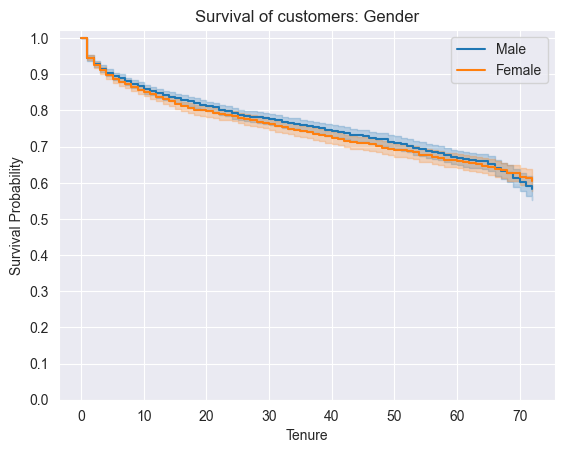

In [60]:
male = (survivaldata['gender_Male'] == 1)
female = (survivaldata['gender_Male'] == 0)

plt.figure()
ax = plt.subplot(1,1,1)

kmf.fit(timevar[male],event_observed = eventvar[male],label = "Male")
plot1 = kmf.plot(ax = ax)

kmf.fit(timevar[female],event_observed = eventvar[female],label = "Female")
plot2 = kmf.plot(ax = plot1)

plt.title('Survival of customers: Gender')
plt.xlabel('Tenure')
plt.ylabel('Survival Probability')
plt.yticks(np.linspace(0,1,11))
groups = logrank_test(timevar[male], timevar[female], event_observed_A=eventvar[male], event_observed_B=eventvar[female])
groups.print_summary()

### Senior Citizen

<lifelines.StatisticalResult: logrank_test>
               t_0 = -1
 null_distribution = chi squared
degrees_of_freedom = 1
         test_name = logrank_test

---
 test_statistic      p  -log2(p)
         109.49 <0.005     82.71

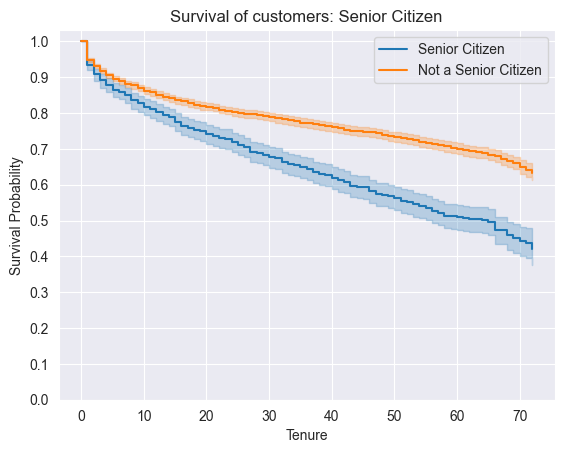

In [61]:
SeniorCitizen = (survivaldata['SeniorCitizen_1'] == 1)
no_SeniorCitizen = (survivaldata['SeniorCitizen_1'] == 0)

plt.figure()
ax = plt.subplot(1,1,1)

kmf.fit(timevar[SeniorCitizen],event_observed = eventvar[SeniorCitizen],label = "Senior Citizen")
plot1 = kmf.plot(ax = ax)

kmf.fit(timevar[no_SeniorCitizen],event_observed = eventvar[no_SeniorCitizen],label = "Not a Senior Citizen")
plot2 = kmf.plot(ax = plot1)

plt.title('Survival of customers: Senior Citizen')
plt.xlabel('Tenure')
plt.ylabel('Survival Probability')
plt.yticks(np.linspace(0,1,11))
groups = logrank_test(timevar[SeniorCitizen], timevar[no_SeniorCitizen], event_observed_A=eventvar[SeniorCitizen], event_observed_B=eventvar[no_SeniorCitizen])
groups.print_summary()

### Partner

<lifelines.StatisticalResult: logrank_test>
               t_0 = -1
 null_distribution = chi squared
degrees_of_freedom = 1
         test_name = logrank_test

---
 test_statistic      p  -log2(p)
         423.54 <0.005    310.21

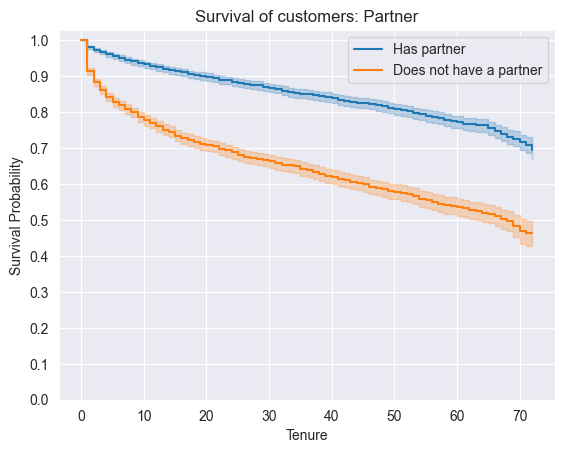

In [62]:
partner = (survivaldata['Partner_Yes'] == 1)
no_partner = (survivaldata['Partner_Yes'] == 0)

plt.figure()
ax = plt.subplot(1,1,1)

kmf.fit(timevar[partner],event_observed = eventvar[partner],label = "Has partner")
plot1 = kmf.plot(ax = ax)

kmf.fit(timevar[no_partner],event_observed = eventvar[no_partner],label = "Does not have a partner")
plot2 = kmf.plot(ax = plot1)

plt.title('Survival of customers: Partner')
plt.xlabel('Tenure')
plt.ylabel('Survival Probability')
plt.yticks(np.linspace(0,1,11))
groups = logrank_test(timevar[partner], timevar[no_partner], event_observed_A=eventvar[partner], event_observed_B=eventvar[no_partner])
groups.print_summary()

### Dependents

<lifelines.StatisticalResult: logrank_test>
               t_0 = -1
 null_distribution = chi squared
degrees_of_freedom = 1
         test_name = logrank_test

---
 test_statistic      p  -log2(p)
         232.70 <0.005    172.12

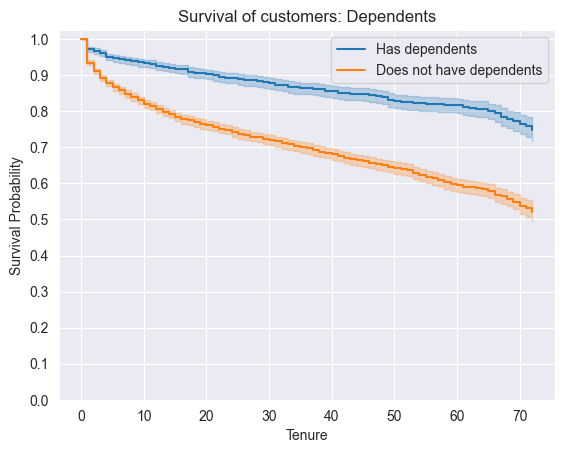

In [63]:
Dependents = (survivaldata['Dependents_Yes'] == 1)
no_Dependents = (survivaldata['Dependents_Yes'] == 0)

plt.figure()
ax = plt.subplot(1,1,1)

kmf.fit(timevar[Dependents],event_observed = eventvar[Dependents],label = "Has dependents")
plot1 = kmf.plot(ax = ax)

kmf.fit(timevar[no_Dependents],event_observed = eventvar[no_Dependents],label = "Does not have dependents")
plot2 = kmf.plot(ax = plot1)

plt.title('Survival of customers: Dependents')
plt.xlabel('Tenure')
plt.ylabel('Survival Probability')
plt.yticks(np.linspace(0,1,11))
groups = logrank_test(timevar[Dependents], timevar[no_Dependents], event_observed_A=eventvar[Dependents], event_observed_B=eventvar[no_Dependents])
groups.print_summary()

### PhoneService

<lifelines.StatisticalResult: logrank_test>
               t_0 = -1
 null_distribution = chi squared
degrees_of_freedom = 1
         test_name = logrank_test

---
 test_statistic    p  -log2(p)
           0.43 0.51      0.97

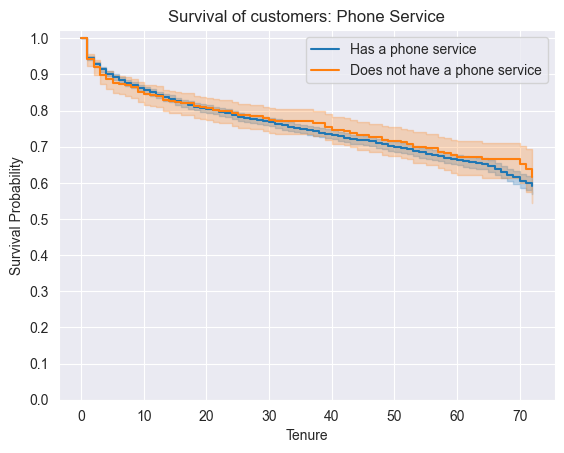

In [64]:
PhoneService = (survivaldata['PhoneService_Yes'] == 1)
no_PhoneService = (survivaldata['PhoneService_Yes'] == 0)

plt.figure()
ax = plt.subplot(1,1,1)

kmf.fit(timevar[PhoneService],event_observed = eventvar[PhoneService],label = "Has a phone service")
plot1 = kmf.plot(ax = ax)

kmf.fit(timevar[no_PhoneService],event_observed = eventvar[no_PhoneService],label = "Does not have a phone service")
plot2 = kmf.plot(ax = plot1)

plt.title('Survival of customers: Phone Service')
plt.xlabel('Tenure')
plt.ylabel('Survival Probability')
plt.yticks(np.linspace(0,1,11))
groups = logrank_test(timevar[PhoneService], timevar[no_PhoneService], event_observed_A=eventvar[PhoneService], event_observed_B=eventvar[no_PhoneService])
groups.print_summary()

### MultipleLines

<lifelines.StatisticalResult: multivariate_logrank_test>
               t_0 = -1
 null_distribution = chi squared
degrees_of_freedom = 2
             alpha = 0.95
         test_name = multivariate_logrank_test

---
 test_statistic      p  -log2(p)
          30.97 <0.005     22.34

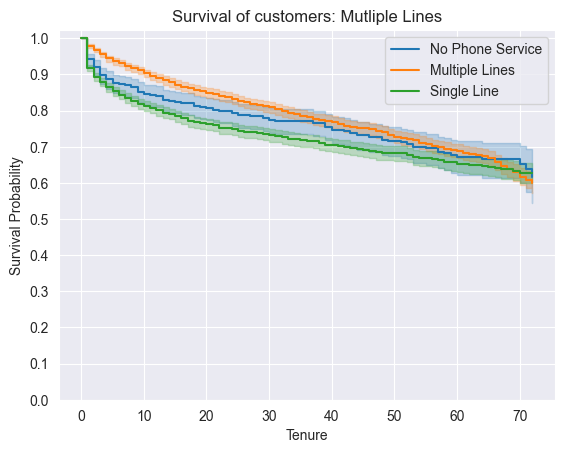

In [65]:
no_phone = (survivaldata['MultipleLines_No phone service'] == 1)
multiLines = (survivaldata['MultipleLines_Yes'] == 1)
no_multiLines = ((survivaldata['MultipleLines_Yes'] == 0) & (survivaldata['MultipleLines_No phone service'] == 0))

plt.figure()
ax = plt.subplot(1,1,1)

kmf.fit(timevar[no_phone],event_observed = eventvar[no_phone],label = "No Phone Service")
plot1 = kmf.plot(ax = ax)

kmf.fit(timevar[multiLines],event_observed = eventvar[multiLines],label = "Multiple Lines")
plot2 = kmf.plot(ax = plot1)

kmf.fit(timevar[no_multiLines],event_observed = eventvar[no_multiLines],label = "Single Line")
plot3 = kmf.plot(ax = plot2)

plt.title('Survival of customers: Mutliple Lines')
plt.xlabel('Tenure')
plt.ylabel('Survival Probability')
plt.yticks(np.linspace(0,1,11))
twoplusgroups_logrank = multivariate_logrank_test(df_surv['tenure'], df_surv['MultipleLines'], df_surv['Churn'], alpha = 0.95)
twoplusgroups_logrank.print_summary()

### Internet Service

<lifelines.StatisticalResult: multivariate_logrank_test>
               t_0 = -1
 null_distribution = chi squared
degrees_of_freedom = 2
             alpha = 0.95
         test_name = multivariate_logrank_test

---
 test_statistic      p  -log2(p)
         520.12 <0.005    375.19

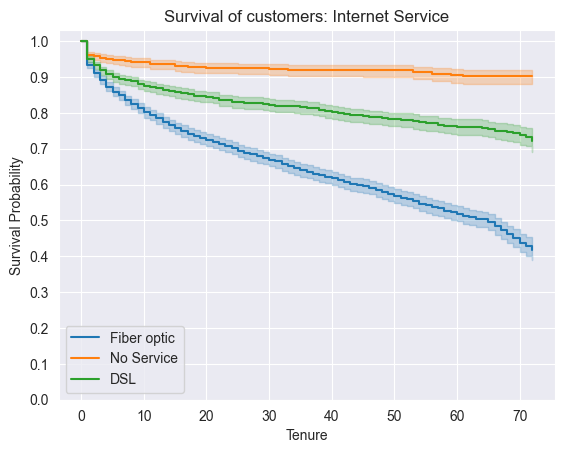

In [66]:
Fiber_optic = (survivaldata['InternetService_Fiber optic'] == 1)
No_Service = (survivaldata['InternetService_No'] == 1)
DSL = ((survivaldata['InternetService_Fiber optic'] == 0) & (survivaldata['InternetService_No'] == 0))

plt.figure()
ax = plt.subplot(1,1,1)

kmf.fit(timevar[Fiber_optic],event_observed = eventvar[Fiber_optic],label = "Fiber optic")
plot1 = kmf.plot(ax = ax)

kmf.fit(timevar[No_Service],event_observed = eventvar[No_Service],label = "No Service")
plot2 = kmf.plot(ax = plot1)

kmf.fit(timevar[DSL],event_observed = eventvar[DSL],label = "DSL")
plot3 = kmf.plot(ax = plot2)

plt.title('Survival of customers: Internet Service')
plt.xlabel('Tenure')
plt.ylabel('Survival Probability')
plt.yticks(np.linspace(0,1,11))
twoplusgroups_logrank = multivariate_logrank_test(df_surv['tenure'], df_surv['InternetService'], df_surv['Churn'], alpha = 0.95)
twoplusgroups_logrank.print_summary()

### Online Security

<lifelines.StatisticalResult: multivariate_logrank_test>
               t_0 = -1
 null_distribution = chi squared
degrees_of_freedom = 2
             alpha = 0.95
         test_name = multivariate_logrank_test

---
 test_statistic      p  -log2(p)
        1013.86 <0.005    731.35

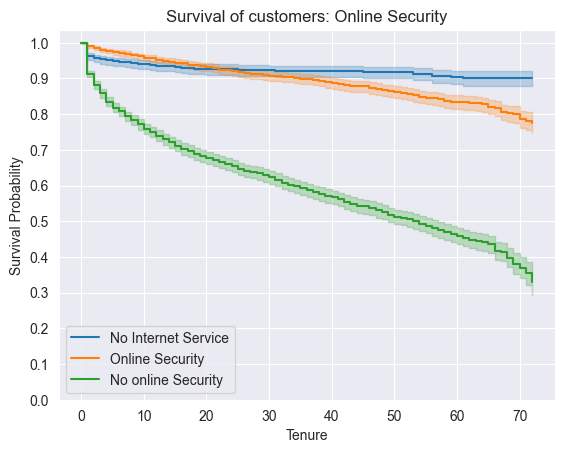

In [67]:
no_internetService = (survivaldata['OnlineSecurity_No internet service'] == 1)
onlineSecurity = (survivaldata['OnlineSecurity_Yes'] == 1)
no_onlineSecurity = ((survivaldata['OnlineSecurity_No internet service'] == 0) & (survivaldata['OnlineSecurity_Yes'] == 0))

plt.figure()
ax = plt.subplot(1,1,1)

kmf.fit(timevar[no_internetService],event_observed = eventvar[no_internetService],label = "No Internet Service")
plot1 = kmf.plot(ax = ax)

kmf.fit(timevar[onlineSecurity],event_observed = eventvar[onlineSecurity],label = "Online Security")
plot2 = kmf.plot(ax = plot1)

kmf.fit(timevar[no_onlineSecurity],event_observed = eventvar[no_onlineSecurity],label = "No online Security")
plot3 = kmf.plot(ax = plot2)

plt.title('Survival of customers: Online Security')
plt.xlabel('Tenure')
plt.ylabel('Survival Probability')
plt.yticks(np.linspace(0,1,11))
twoplusgroups_logrank = multivariate_logrank_test(df_surv['tenure'], df_surv['OnlineSecurity'], df_surv['Churn'], alpha = 0.95)
twoplusgroups_logrank.print_summary()

### Online Backup

<lifelines.StatisticalResult: multivariate_logrank_test>
               t_0 = -1
 null_distribution = chi squared
degrees_of_freedom = 2
             alpha = 0.95
         test_name = multivariate_logrank_test

---
 test_statistic      p  -log2(p)
         821.34 <0.005    592.47

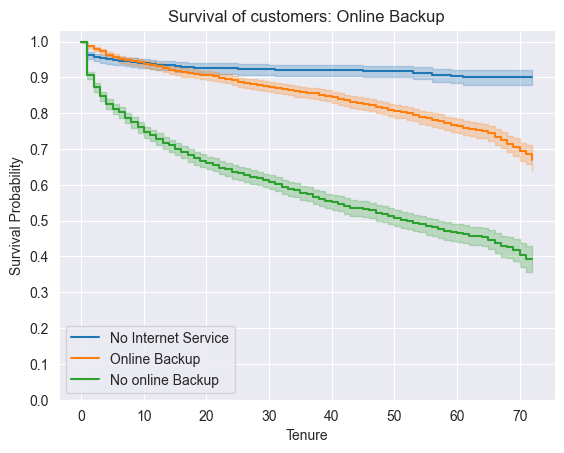

In [68]:
no_internetService = (survivaldata['OnlineBackup_No internet service'] == 1)
onlineBackup = (survivaldata['OnlineBackup_Yes'] == 1)
no_onlineBackup = ((survivaldata['OnlineBackup_No internet service'] == 0) & (survivaldata['OnlineBackup_Yes'] == 0))

plt.figure()
ax = plt.subplot(1,1,1)

kmf.fit(timevar[no_internetService],event_observed = eventvar[no_internetService],label = "No Internet Service")
plot1 = kmf.plot(ax = ax)

kmf.fit(timevar[onlineBackup],event_observed = eventvar[onlineBackup],label = "Online Backup")
plot2 = kmf.plot(ax = plot1)

kmf.fit(timevar[no_onlineBackup],event_observed = eventvar[no_onlineBackup],label = "No online Backup")
plot3 = kmf.plot(ax = plot2)

plt.title('Survival of customers: Online Backup')
plt.xlabel('Tenure')
plt.ylabel('Survival Probability')
plt.yticks(np.linspace(0,1,11))
twoplusgroups_logrank = multivariate_logrank_test(df_surv['tenure'], df_surv['OnlineBackup'], df_surv['Churn'], alpha = 0.95)
twoplusgroups_logrank.print_summary()

### Device Protection

<lifelines.StatisticalResult: multivariate_logrank_test>
               t_0 = -1
 null_distribution = chi squared
degrees_of_freedom = 2
             alpha = 0.95
         test_name = multivariate_logrank_test

---
 test_statistic      p  -log2(p)
         763.51 <0.005    550.75

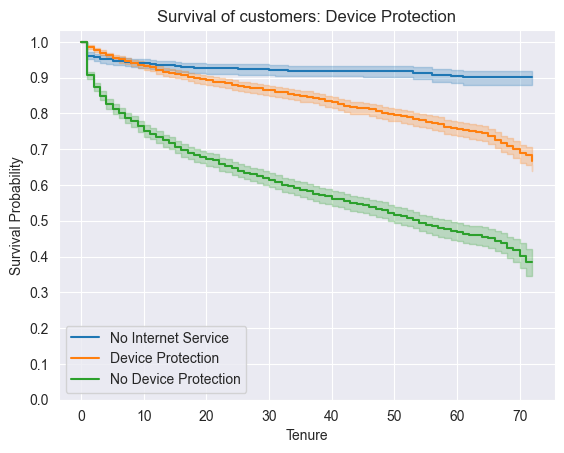

In [69]:
no_internetService = (survivaldata['DeviceProtection_No internet service'] == 1)
DeviceProtection = (survivaldata['DeviceProtection_Yes'] == 1)
no_DeviceProtection = ((survivaldata['DeviceProtection_No internet service'] == 0) & (survivaldata['DeviceProtection_Yes'] == 0))

plt.figure()
ax = plt.subplot(1,1,1)

kmf.fit(timevar[no_internetService],event_observed = eventvar[no_internetService],label = "No Internet Service")
plot1 = kmf.plot(ax = ax)

kmf.fit(timevar[DeviceProtection],event_observed = eventvar[DeviceProtection],label = "Device Protection")
plot2 = kmf.plot(ax = plot1)

kmf.fit(timevar[no_DeviceProtection],event_observed = eventvar[no_DeviceProtection],label = "No Device Protection")
plot3 = kmf.plot(ax = plot2)

plt.title('Survival of customers: Device Protection')
plt.xlabel('Tenure')
plt.ylabel('Survival Probability')
plt.yticks(np.linspace(0,1,11))
twoplusgroups_logrank = multivariate_logrank_test(df_surv['tenure'], df_surv['DeviceProtection'], df_surv['Churn'], alpha = 0.95)
twoplusgroups_logrank.print_summary()

### Tech Support

<lifelines.StatisticalResult: multivariate_logrank_test>
               t_0 = -1
 null_distribution = chi squared
degrees_of_freedom = 2
             alpha = 0.95
         test_name = multivariate_logrank_test

---
 test_statistic      p  -log2(p)
         989.56 <0.005    713.82

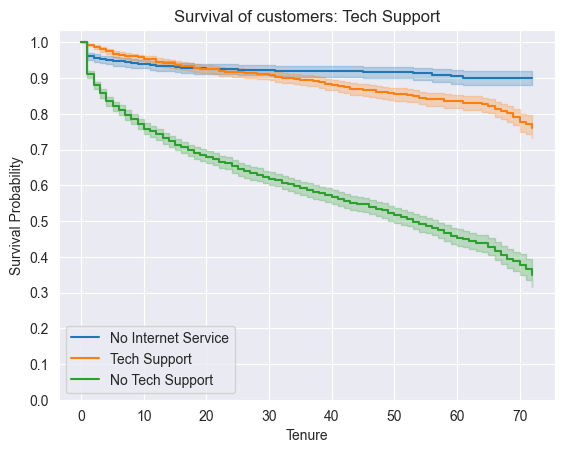

In [70]:
no_internetService = (survivaldata['TechSupport_No internet service'] == 1)
TechSupport = (survivaldata['TechSupport_Yes'] == 1)
no_TechSupport = ((survivaldata['TechSupport_No internet service'] == 0) & (survivaldata['TechSupport_Yes'] == 0))

plt.figure()
ax = plt.subplot(1,1,1)

kmf.fit(timevar[no_internetService],event_observed = eventvar[no_internetService],label = "No Internet Service")
plot1 = kmf.plot(ax = ax)

kmf.fit(timevar[TechSupport],event_observed = eventvar[TechSupport],label = "Tech Support")
plot2 = kmf.plot(ax = plot1)

kmf.fit(timevar[no_TechSupport],event_observed = eventvar[no_TechSupport],label = "No Tech Support")
plot3 = kmf.plot(ax = plot2)

plt.title('Survival of customers: Tech Support')
plt.xlabel('Tenure')
plt.ylabel('Survival Probability')
plt.yticks(np.linspace(0,1,11))
twoplusgroups_logrank = multivariate_logrank_test(df_surv['tenure'], df_surv['TechSupport'], df_surv['Churn'], alpha = 0.95)
twoplusgroups_logrank.print_summary()

### Streaming TV

<lifelines.StatisticalResult: multivariate_logrank_test>
               t_0 = -1
 null_distribution = chi squared
degrees_of_freedom = 2
             alpha = 0.95
         test_name = multivariate_logrank_test

---
 test_statistic      p  -log2(p)
         368.31 <0.005    265.68

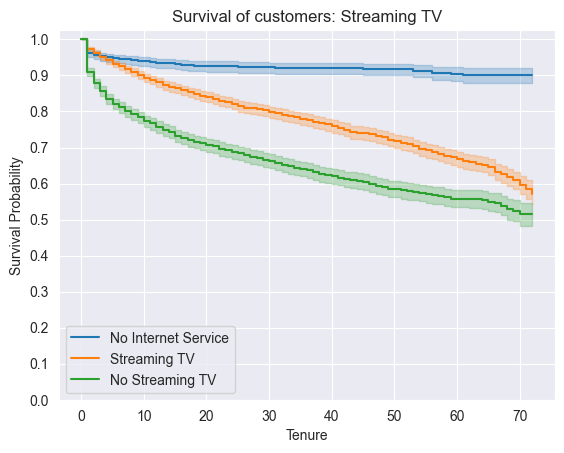

In [71]:
no_internetService = (survivaldata['StreamingTV_No internet service'] == 1)
StreamingTV = (survivaldata['StreamingTV_Yes'] == 1)
no_StreamingTV = ((survivaldata['StreamingTV_No internet service'] == 0) & (survivaldata['StreamingTV_Yes'] == 0))

plt.figure()
ax = plt.subplot(1,1,1)

kmf.fit(timevar[no_internetService],event_observed = eventvar[no_internetService],label = "No Internet Service")
plot1 = kmf.plot(ax = ax)

kmf.fit(timevar[StreamingTV],event_observed = eventvar[StreamingTV],label = "Streaming TV")
plot2 = kmf.plot(ax = plot1)

kmf.fit(timevar[no_StreamingTV],event_observed = eventvar[no_StreamingTV],label = "No Streaming TV")
plot3 = kmf.plot(ax = plot2)

plt.title('Survival of customers: Streaming TV')
plt.xlabel('Tenure')
plt.ylabel('Survival Probability')
plt.yticks(np.linspace(0,1,11))
twoplusgroups_logrank = multivariate_logrank_test(df_surv['tenure'], df_surv['StreamingTV'], df_surv['Churn'], alpha = 0.95)
twoplusgroups_logrank.print_summary()

### Streaming Movies

<lifelines.StatisticalResult: multivariate_logrank_test>
               t_0 = -1
 null_distribution = chi squared
degrees_of_freedom = 2
             alpha = 0.95
         test_name = multivariate_logrank_test

---
 test_statistic      p  -log2(p)
         378.43 <0.005    272.98

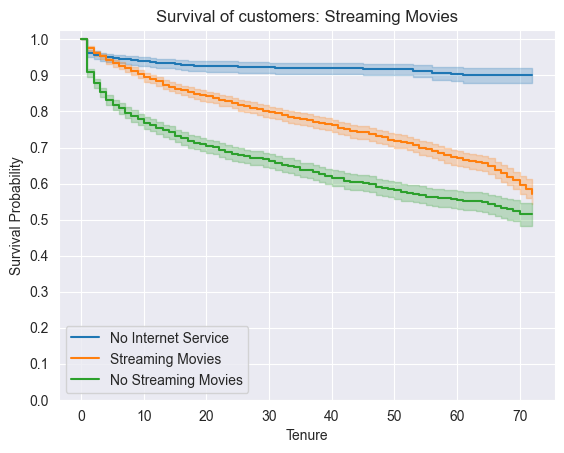

In [72]:
no_internetService = (survivaldata['StreamingMovies_No internet service'] == 1)
StreamingMovies = (survivaldata['StreamingMovies_Yes'] == 1)
no_StreamingMovies = ((survivaldata['StreamingMovies_No internet service'] == 0) & (survivaldata['StreamingMovies_Yes'] == 0))

plt.figure()
ax = plt.subplot(1,1,1)

kmf.fit(timevar[no_internetService],event_observed = eventvar[no_internetService],label = "No Internet Service")
plot1 = kmf.plot(ax = ax)

kmf.fit(timevar[StreamingMovies],event_observed = eventvar[StreamingMovies],label = "Streaming Movies")
plot2 = kmf.plot(ax = plot1)

kmf.fit(timevar[no_StreamingMovies],event_observed = eventvar[no_StreamingMovies],label = "No Streaming Movies")
plot3 = kmf.plot(ax = plot2)

plt.title('Survival of customers: Streaming Movies')
plt.xlabel('Tenure')
plt.ylabel('Survival Probability')
plt.yticks(np.linspace(0,1,11))
twoplusgroups_logrank = multivariate_logrank_test(df_surv['tenure'], df_surv['StreamingMovies'], df_surv['Churn'], alpha = 0.95)
twoplusgroups_logrank.print_summary()

### Contract

<lifelines.StatisticalResult: multivariate_logrank_test>
               t_0 = -1
 null_distribution = chi squared
degrees_of_freedom = 2
             alpha = 0.95
         test_name = multivariate_logrank_test

---
 test_statistic      p  -log2(p)
        2352.87 <0.005       inf

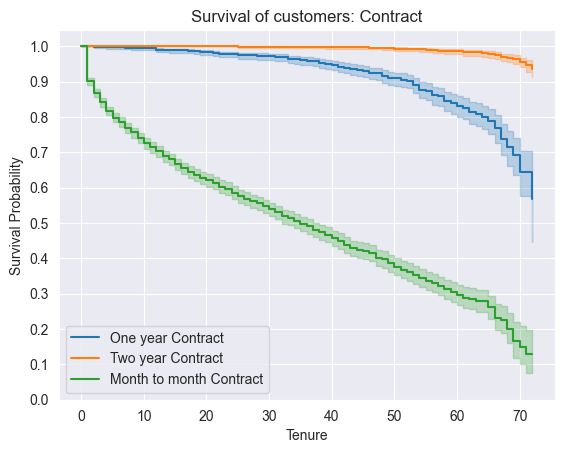

In [73]:
Contract_One_year = (survivaldata['Contract_One year'] == 1)
Contract_Two_year = (survivaldata['Contract_Two year'] == 1)
Contract_month_to_month = ((survivaldata['Contract_One year'] == 0) & (survivaldata['Contract_Two year'] == 0))

plt.figure()
ax = plt.subplot(1,1,1)

kmf.fit(timevar[Contract_One_year],event_observed = eventvar[Contract_One_year],label = "One year Contract")
plot1 = kmf.plot(ax = ax)

kmf.fit(timevar[Contract_Two_year],event_observed = eventvar[Contract_Two_year],label = "Two year Contract")
plot2 = kmf.plot(ax = plot1)

kmf.fit(timevar[Contract_month_to_month],event_observed = eventvar[Contract_month_to_month],label = "Month to month Contract")
plot3 = kmf.plot(ax = plot2)

plt.title('Survival of customers: Contract')
plt.xlabel('Tenure')
plt.ylabel('Survival Probability')
plt.yticks(np.linspace(0,1,11))
twoplusgroups_logrank = multivariate_logrank_test(df_surv['tenure'], df_surv['Contract'], df_surv['Churn'], alpha = 0.95)
twoplusgroups_logrank.print_summary()

### Payment Method

<lifelines.StatisticalResult: multivariate_logrank_test>
               t_0 = -1
 null_distribution = chi squared
degrees_of_freedom = 3
             alpha = 0.95
         test_name = multivariate_logrank_test

---
 test_statistic      p  -log2(p)
         865.24 <0.005    619.58

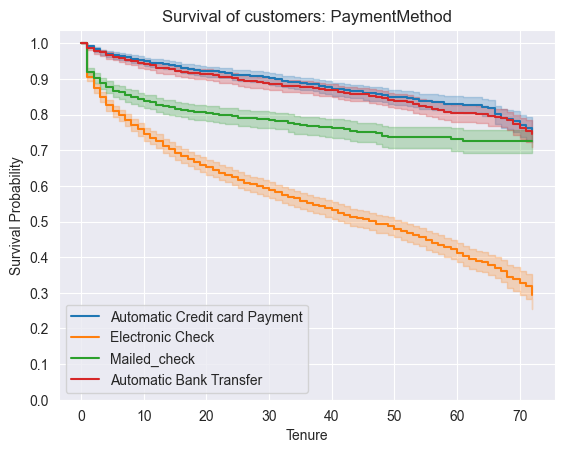

In [74]:
automatic_Credit_Card = (survivaldata['PaymentMethod_Credit card (automatic)'] == 1)
electronic_check = (survivaldata['PaymentMethod_Electronic check'] == 1)
mailed_check = (survivaldata['PaymentMethod_Mailed check'] == 1)
automatic_Bank_Transfer = ((survivaldata['PaymentMethod_Credit card (automatic)'] == 0) & (survivaldata['PaymentMethod_Electronic check'] == 0) & (survivaldata['PaymentMethod_Mailed check'] == 0))

plt.figure()
ax = plt.subplot(1,1,1)

kmf.fit(timevar[automatic_Credit_Card],event_observed = eventvar[automatic_Credit_Card],label = "Automatic Credit card Payment")
plot1 = kmf.plot(ax = ax)

kmf.fit(timevar[electronic_check],event_observed = eventvar[electronic_check],label = "Electronic Check")
plot2 = kmf.plot(ax = plot1)

kmf.fit(timevar[mailed_check],event_observed = eventvar[mailed_check],label = "Mailed_check")
plot3 = kmf.plot(ax = plot2)

kmf.fit(timevar[automatic_Bank_Transfer],event_observed = eventvar[automatic_Bank_Transfer],label = "Automatic Bank Transfer")
plot4 = kmf.plot(ax = plot3)

plt.title('Survival of customers: PaymentMethod')
plt.xlabel('Tenure')
plt.ylabel('Survival Probability')
plt.yticks(np.linspace(0,1,11))
twoplusgroups_logrank = multivariate_logrank_test(df_surv['tenure'], df_surv['PaymentMethod'], df_surv['Churn'], alpha = 0.95)
twoplusgroups_logrank.print_summary()

### Paperless Billing

<lifelines.StatisticalResult: logrank_test>
               t_0 = -1
 null_distribution = chi squared
degrees_of_freedom = 1
         test_name = logrank_test

---
 test_statistic      p  -log2(p)
         189.51 <0.005    140.82

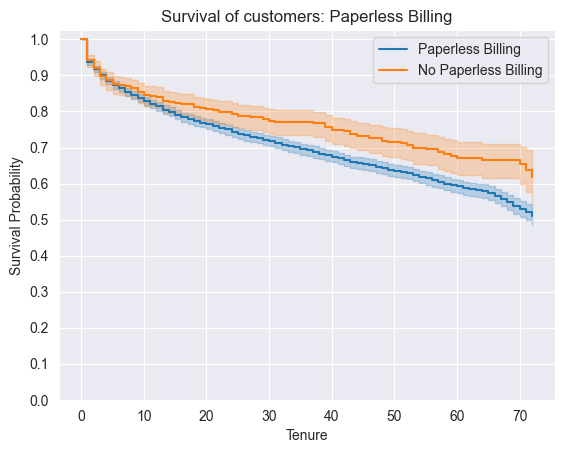

In [75]:
PaperlessBilling = (survivaldata['PaperlessBilling_Yes'] == 1)
no_PaperlessBilling = (survivaldata['PaperlessBilling_Yes'] == 0)

plt.figure()
ax = plt.subplot(1,1,1)

kmf.fit(timevar[PaperlessBilling],event_observed = eventvar[PaperlessBilling],label = "Paperless Billing")
plot1 = kmf.plot(ax = ax)

kmf.fit(timevar[no_PhoneService],event_observed = eventvar[no_PhoneService],label = "No Paperless Billing")
plot2 = kmf.plot(ax = plot1)

plt.title('Survival of customers: Paperless Billing')
plt.xlabel('Tenure')
plt.ylabel('Survival Probability')
plt.yticks(np.linspace(0,1,11))
groups = logrank_test(timevar[PaperlessBilling], timevar[no_PaperlessBilling], event_observed_A=eventvar[PaperlessBilling], event_observed_B=eventvar[no_PaperlessBilling])
groups.print_summary()

## Survival Regression

In [76]:
regression_df = datapreparation(DATA_PATH)
regression_df.head()

/var/folders/41/f97k2tlx2xnftr7h0sg_bp4r0000gn/T/ipykernel_10525/52434926.py:7: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df.TotalCharges.fillna(0, inplace = True)


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,OnlineSecurity,OnlineBackup,DeviceProtection,...,MonthlyCharges,TotalCharges,Churn,InternetService_Fiber optic,InternetService_No,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,1,0,1,0,1,0,0,0,1,0,...,29.85,29.85,0,False,False,False,False,False,True,False
1,0,0,0,0,34,1,0,1,0,1,...,56.95,1889.50,0,False,False,True,False,False,False,True
2,0,0,0,0,2,1,0,1,1,0,...,53.85,108.15,1,False,False,False,False,False,False,True
3,0,0,0,0,45,0,0,1,0,1,...,42.30,1840.75,0,False,False,True,False,False,False,False
4,1,0,0,0,2,1,0,0,0,0,...,70.70,151.65,1,True,False,False,False,False,True,False


#### Survival Regression Analysis using Cox Proportional Hazard model

In [77]:
cph = CoxPHFitter()
cph.fit(regression_df, duration_col='tenure', event_col='Churn')

cph.print_summary()

<lifelines.CoxPHFitter: fitted with 7043 total observations, 5174 right-censored observations>
             duration col = 'tenure'
                event col = 'Churn'
      baseline estimation = breslow
   number of observations = 7043
number of events observed = 1869
   partial log-likelihood = -12659.69
         time fit was run = 2026-07-04 03:56:05 UTC

---
                                       coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                                              
gender                                 0.04      1.04      0.05           -0.05            0.13                0.95                1.14
SeniorCitizen                          0.03      1.04      0.06           -0.08            0.15                0.93                1.16
Partner                               -0.18      0.84      0.06           -0.29           -0.07                0.75                0.93
Dependents                            -0.09      0.91      0.07           -0.23            0.05                0.80                1.05
PhoneService                           0.83      2.29      0.47           -0.10            1.76                0.90                5.80
MultipleLines                          0.09      1.09      0.13           -0.16            0.33                0.85                1.40
OnlineSecurity                        -0.21      0.81      0.13           -0.47            0.05                0.62                1.05
OnlineBackup                          -0.06      0.95      0.13           -0.31            0.19                0.74                1.21
DeviceProtection                       0.09      1.09      0.13           -0.16            0.34                0.85                1.40
TechSupport                           -0.08      0.92      0.13           -0.34            0.17                0.71                1.19
StreamingTV                            0.28      1.32      0.24           -0.18            0.74                0.83                2.10
StreamingMovies                        0.29      1.33      0.24           -0.18            0.75                0.84                2.11
PaperlessBilling                       0.15      1.16      0.06            0.04            0.26                1.04                1.30
MonthlyCharges                         0.01      1.01      0.02           -0.03            0.06                0.97                1.06
TotalCharges                          -0.00      1.00      0.00           -0.00           -0.00                1.00                1.00
InternetService_Fiber optic            1.02      2.77      0.58           -0.12            2.15                0.89                8.59
InternetService_No                    -2.34      0.10      0.60           -3.51           -1.17                0.03                0.31
Contract_One year                     -1.27      0.28      0.10           -1.46           -1.07                0.23                0.34
Contract_Two year                     -3.70      0.02      0.20           -4.10           -3.31                0.02                0.04
PaymentMethod_Credit card (automatic) -0.01      0.99      0.09           -0.19            0.17                0.83                1.18
PaymentMethod_Electronic check         0.39      1.47      0.07            0.24            0.53                1.28                1.70
PaymentMethod_Mailed check             0.51      1.67      0.09            0.34            0.68                1.40                1.98

                                       cmp to      z      p  -log2(p)
covariate                                                            
gender                                   0.00   0.85   0.40      1.33
SeniorCitizen                            0.00   0.61   0.54      0.88
Partner                                  0.00  -3.23 <0.005      9.67
Dependents          

In [78]:
cph.log_likelihood_

np.float64(-12659.692898720215)

In [79]:
cph.AIC_partial_

np.float64(25363.38579744043)

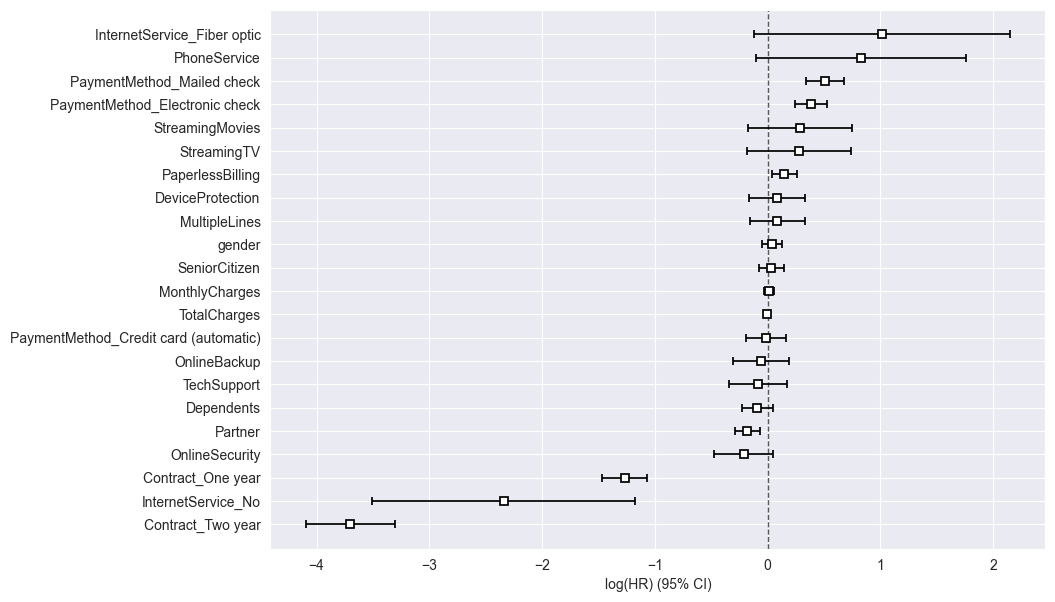

In [80]:
fig, ax = plt.subplots(figsize = (10,7))
cph.plot(ax = ax);

In [81]:
test_id = regression_df.sample(1)

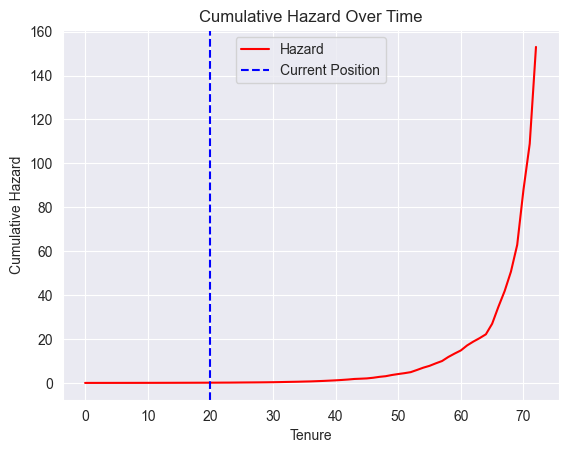

In [82]:
fig, ax = plt.subplots()
cph.predict_cumulative_hazard(test_id).plot(ax = ax, color = 'red')
plt.axvline(x=test_id.tenure.values[0], color = 'blue', linestyle='--')
plt.legend(labels=['Hazard','Current Position'])
ax.set_xlabel('Tenure', size = 10)
ax.set_ylabel('Cumulative Hazard', size = 10)
ax.set_title('Cumulative Hazard Over Time');

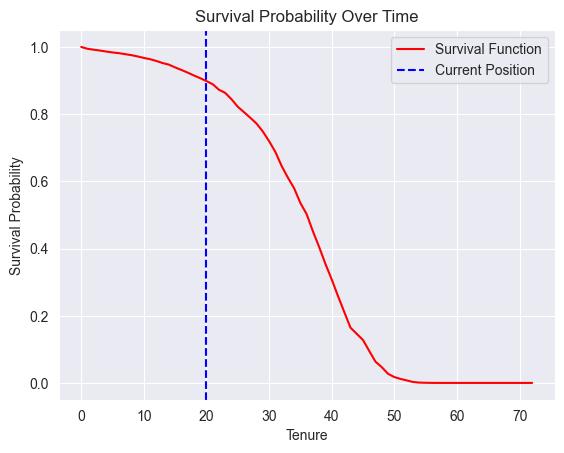

In [83]:
fig, ax = plt.subplots()
cph.predict_survival_function(test_id).plot(ax = ax, color = 'red')
plt.axvline(x=test_id.tenure.values[0], color = 'blue', linestyle='--')
plt.legend(labels=['Survival Function','Current Position'])
ax.set_xlabel('Tenure', size = 10)
ax.set_ylabel('Survival Probability', size = 10)
ax.set_title('Survival Probability Over Time');

Saving the model

In [84]:
pickle.dump(cph, open('survivemodel.pkl','wb'))

## Customer Lifetime Value

To calculate customer lifetime value, I would multiply the Monthly charges the customer is paying to Telcom and the expected life time of the customer.

I utilize the survival function of a customer to calculate its expected life time. I would like to be little bit conservative and consider the customer is churned when the survival probability of him is 10%.

In [85]:
def LTV(info):
    life = cph.predict_survival_function(info).reset_index()
    life.columns = ['Tenure', 'Probability']
    max_life = life.Tenure[life.Probability > 0.1].max()

    LTV = max_life * info['MonthlyCharges'].values[0]
    return LTV

In [86]:
print('LTV of a testid is:', LTV(test_id), 'dollars.')

LTV of a testid is: 2475.0 dollars.


# 3. Churn Prediction Modeling

## 3.1 Data Preparation

In [87]:
model_df = datapreparation(DATA_PATH)
model_df.isnull().any().any()

/var/folders/41/f97k2tlx2xnftr7h0sg_bp4r0000gn/T/ipykernel_10525/52434926.py:7: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df.TotalCharges.fillna(0, inplace = True)


np.False_

## 3.2 Random Forest — Hyperparameter Tuning

We build and tune a Random Forest model first, since tree-based methods tend to perform well on this kind of mixed categorical/numeric tabular data, and they let us inspect individual customers' churn probability and explain it later with SHAP.

In [88]:
train, test = train_test_split(model_df, test_size=0.2, random_state=111, stratify = model_df.Churn)

In [89]:
x = model_df.columns[model_df.columns!="Churn"]
y = "Churn"
train_x = train[x]
train_y = train[y]
test_x = test[x]
test_y = test[y]

In [90]:
#function for model fitting
def churn_prediction(algo, training_x, training_y, testing_x, testing_y, cols, cf = 'coefficients'):
    algo.fit(training_x,training_y)
    predictions = algo.predict(testing_x)
    probabilities = algo.predict_proba(testing_x)[:,1]

    #coeffs
    if cf == "coefficients":
        coefficients = pd.DataFrame(algo.coef_.ravel())
    elif cf == "features":
        coefficients = pd.DataFrame(algo.feature_importances_)

    column_df = pd.DataFrame(cols)
    coef_sumry = (pd.merge(coefficients,column_df,left_index= True,
                              right_index= True, how = "left"))
    coef_sumry.columns = ["coefficients","features"]
    coef_sumry = coef_sumry.sort_values(by = "coefficients",ascending = False)

    print (algo)
    print ("\n Classification report : \n",classification_report(testing_y,predictions))
    print ("Accuracy   Score : ",accuracy_score(testing_y,predictions))

    #confusion matrix
    conf_matrix = confusion_matrix(testing_y,predictions)
    plt.figure(figsize=(12,12))
    plt.subplot(221)
    sns.heatmap(conf_matrix, fmt = "d",annot=True, cmap='Blues')
    plt.title('Confuion Matrix')
    plt.ylabel('True Values')
    plt.xlabel('Predicted Values')

    #roc_auc_score
    model_roc_auc = roc_auc_score(testing_y,probabilities)
    print ("Area under curve : ",model_roc_auc,"\n")
    fpr,tpr,thresholds = roc_curve(testing_y,probabilities)

    plt.subplot(222)
    plt.plot(fpr, tpr, color='darkorange', lw=1, label = "Auc : %.3f" %model_roc_auc)
    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('Receiver operating characteristic')
    plt.legend(loc="lower right")

    plt.subplot(212)
    sns.barplot(x = coef_sumry["features"] ,y = coef_sumry["coefficients"])
    plt.title('Feature Importances')
    plt.xticks(rotation="vertical")

    plt.show()

#### Grid 1: Selecting max_features and n_estimators

In [91]:
param_grid1 = {'max_features':['sqrt', 'log2', None],
          'n_estimators':[300, 500, 700, 900, 1100, 1300]
         }

rf_model = RandomForestClassifier()
grid1 = GridSearchCV(estimator=rf_model, param_grid=param_grid1, n_jobs=-1, cv=3, verbose=1, scoring = 'f1')
grid1.fit(train_x, train_y)

Fitting 3 folds for each of 18 candidates, totalling 54 fits


,estimator,RandomForestClassifier()
,param_grid,"{'max_features': ['sqrt', 'log2', ...], 'n_estimators': [300, 500, ...]}"
,scoring,'f1'
,n_jobs,-1
,refit,True
,cv,3
,verbose,1
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,n_estimators,700


In [92]:
grid1.best_estimator_

,n_estimators,700
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'log2'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


<Axes: xlabel='param_max_features', ylabel='param_n_estimators'>

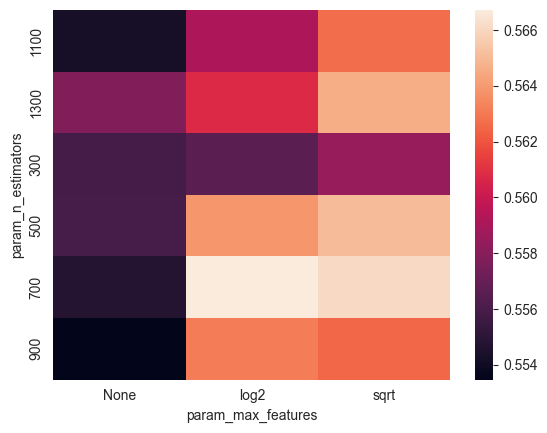

In [93]:
dt = pd.DataFrame(grid1.cv_results_)
dt.param_max_features = dt.param_max_features.astype(str)
dt.param_n_estimators = dt.param_n_estimators.astype(str)

table = pd.pivot_table(dt, values='mean_test_score', index='param_n_estimators',
                       columns='param_max_features')

sns.heatmap(table)

In [94]:
grid1.best_score_

np.float64(0.5667177434036041)

#### Grid 2: Selecting max depth and split criterion

In [95]:
param_grid2 = {
    "n_estimators": [200, 400],
    "max_depth": [None, 10, 20],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "max_features": ["sqrt", "log2", None],
    "bootstrap": [True, False]
}

rf_model = RandomForestClassifier(random_state=42)
grid2 = GridSearchCV(
    estimator=rf_model,
    param_grid=param_grid2,
    n_jobs=-1,
    cv=3,
    verbose=1,
    scoring="f1"
)
grid2.fit(train_x, train_y)

Fitting 3 folds for each of 324 candidates, totalling 972 fits


,estimator,RandomForestC...ndom_state=42)
,param_grid,"{'bootstrap': [True, False], 'max_depth': [None, 10, ...], 'max_features': ['sqrt', 'log2', ...], 'min_samples_leaf': [1, 2, ...], ...}"
,scoring,'f1'
,n_jobs,-1
,refit,True
,cv,3
,verbose,1
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,n_estimators,200


In [96]:
grid2.best_estimator_

,n_estimators,200
,criterion,'gini'
,max_depth,10
,min_samples_split,10
,min_samples_leaf,4
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [97]:
dt = pd.DataFrame(grid2.cv_results_)
[c for c in dt.columns if c.startswith("param_")]

['param_bootstrap',
 'param_max_depth',
 'param_max_features',
 'param_min_samples_leaf',
 'param_min_samples_split',
 'param_n_estimators']

<Axes: xlabel='param_max_features', ylabel='param_max_depth'>

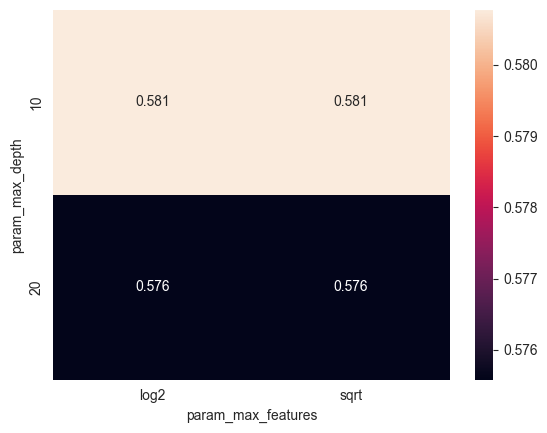

In [98]:
table = pd.pivot_table(
    dt,
    values="mean_test_score",
    index="param_max_depth",
    columns="param_max_features",
    aggfunc="max"
)

sns.heatmap(table, annot=True, fmt=".3f")

<Axes: xlabel='param_n_estimators', ylabel='param_max_depth'>

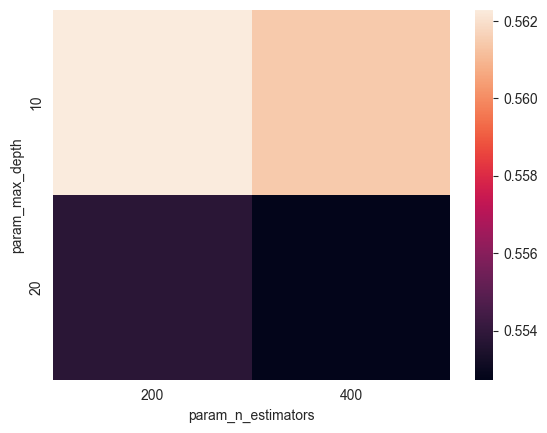

In [99]:
table = pd.pivot_table(dt, values='mean_test_score', index='param_max_depth',
                       columns='param_n_estimators')

sns.heatmap(table)

In [100]:
grid2.best_score_

np.float64(0.5807713725892039)

Checking if other depth and estimator value results better.

*(Merge note: in the original notebook, `param_grid2_2` was referenced before it was defined — a leftover from re-running cells out of order. The dictionary definition is moved first here so the cell runs top-to-bottom.)*

In [101]:
param_grid2_2 = {
    "n_estimators": [200, 400, 600],
    "max_depth": [None, 10, 20],
    "max_features": ["sqrt", "log2", None],
}
rf_model = RandomForestClassifier(random_state=42)
grid2_2 = GridSearchCV(
    estimator=rf_model,
    param_grid=param_grid2_2,
    n_jobs=-1,
    cv=3,
    verbose=1,
    scoring="f1"
)
grid2_2.fit(train_x, train_y)

Fitting 3 folds for each of 27 candidates, totalling 81 fits


,estimator,RandomForestC...ndom_state=42)
,param_grid,"{'max_depth': [None, 10, ...], 'max_features': ['sqrt', 'log2', ...], 'n_estimators': [200, 400, ...]}"
,scoring,'f1'
,n_jobs,-1
,refit,True
,cv,3
,verbose,1
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,n_estimators,200


In [102]:
grid2_2.best_estimator_

,n_estimators,200
,criterion,'gini'
,max_depth,10
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [103]:
grid2_2.best_score_

np.float64(0.579417216079068)

#### Grid 3: Selecting minimum samples leaf and split

*(Merge note: `param_grid3` was also missing its initial definition in the original export. Reconstructed here based on the parameters `grid3` was actually searched over, per the pivot table below.)*

In [104]:
param_grid3 = {
    "min_samples_split": [2, 5, 10, 15],
    "min_samples_leaf": [1, 2, 4, 6],
    "max_features": ["sqrt", "log2", None]
}
rf_model = RandomForestClassifier(random_state=42)

grid3 = GridSearchCV(
    estimator=rf_model,
    param_grid=param_grid3,
    n_jobs=-1,
    cv=3,
    verbose=1,
    scoring="f1"
)

grid3.fit(train_x, train_y)

Fitting 3 folds for each of 48 candidates, totalling 144 fits


,estimator,RandomForestC...ndom_state=42)
,param_grid,"{'max_features': ['sqrt', 'log2', ...], 'min_samples_leaf': [1, 2, ...], 'min_samples_split': [2, 5, ...]}"
,scoring,'f1'
,n_jobs,-1
,refit,True
,cv,3
,verbose,1
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,n_estimators,100


In [105]:
grid3.best_estimator_

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,10
,min_samples_leaf,2
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


<Axes: xlabel='param_min_samples_split', ylabel='param_min_samples_leaf'>

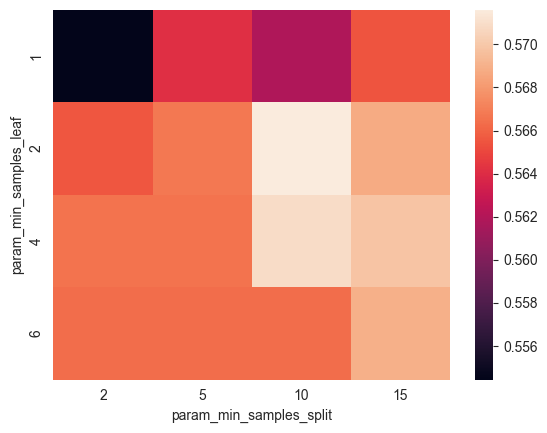

In [106]:
dt = pd.DataFrame(grid3.cv_results_)

table = pd.pivot_table(dt, values='mean_test_score', index='param_min_samples_leaf',
                       columns='param_min_samples_split')

sns.heatmap(table)

In [107]:
grid3.best_score_

np.float64(0.5749350006835022)

#### Grid 4: Selecting class weight

*(Merge note: `param_grid4` was likewise missing its initial definition; reconstructed to search class weighting options, consistent with the grid's title and the `param_class_weight` pivot table below.)*

In [108]:
param_grid4 = {
    "class_weight": [None, "balanced", {0: 1, 1: 2}, {0: 1, 1: 3}],
    "max_features": ["sqrt", "log2", None]
}

rf_model = RandomForestClassifier(random_state=42)

grid4 = GridSearchCV(
    estimator=rf_model,
    param_grid=param_grid4,
    n_jobs=-1,
    cv=3,
    verbose=1,
    scoring="f1"
)

print("Final param_grid being used:\n", grid4.param_grid)  # sanity check
grid4.fit(train_x, train_y)

print("Best params:", grid4.best_params_)
print("Best CV F1:", grid4.best_score_)

Final param_grid being used:
 {'class_weight': [None, 'balanced', {0: 1, 1: 2}, {0: 1, 1: 3}], 'max_features': ['sqrt', 'log2', None]}
Fitting 3 folds for each of 12 candidates, totalling 36 fits
Best params: {'class_weight': {0: 1, 1: 2}, 'max_features': None}
Best CV F1: 0.5556404155687239


In [109]:
grid4.best_estimator_

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


<Axes: ylabel='param_class_weight'>

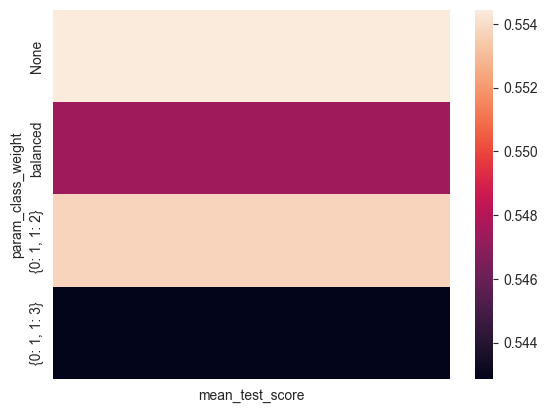

In [110]:
dt = pd.DataFrame(grid4.cv_results_)
dt.param_class_weight = dt.param_class_weight.astype(str)
table = pd.pivot_table(dt, values='mean_test_score', index='param_class_weight')

sns.heatmap(table)

In [111]:
grid4.best_score_

np.float64(0.5556404155687239)

## 3.3 Final Random Forest Model

In [112]:
model = RandomForestClassifier(
    bootstrap=True,
    ccp_alpha=0.0,
    class_weight={0: 1, 1: 2},
    criterion="entropy",
    max_depth=10,
    max_features="sqrt",
    min_samples_leaf=1,
    min_samples_split=8,
    n_estimators=1000,
    random_state=42
)

RandomForestClassifier(class_weight={0: 1, 1: 2}, criterion='entropy',
                       max_depth=10, min_samples_split=8, n_estimators=1000,
                       random_state=42)

 Classification report : 
               precision    recall  f1-score   support

           0       0.87      0.84      0.85      1035
           1       0.59      0.66      0.62       374

    accuracy                           0.79      1409
   macro avg       0.73      0.75      0.74      1409
weighted avg       0.80      0.79      0.79      1409

Accuracy   Score :  0.7877927608232789
Area under curve :  0.8482936784727066 



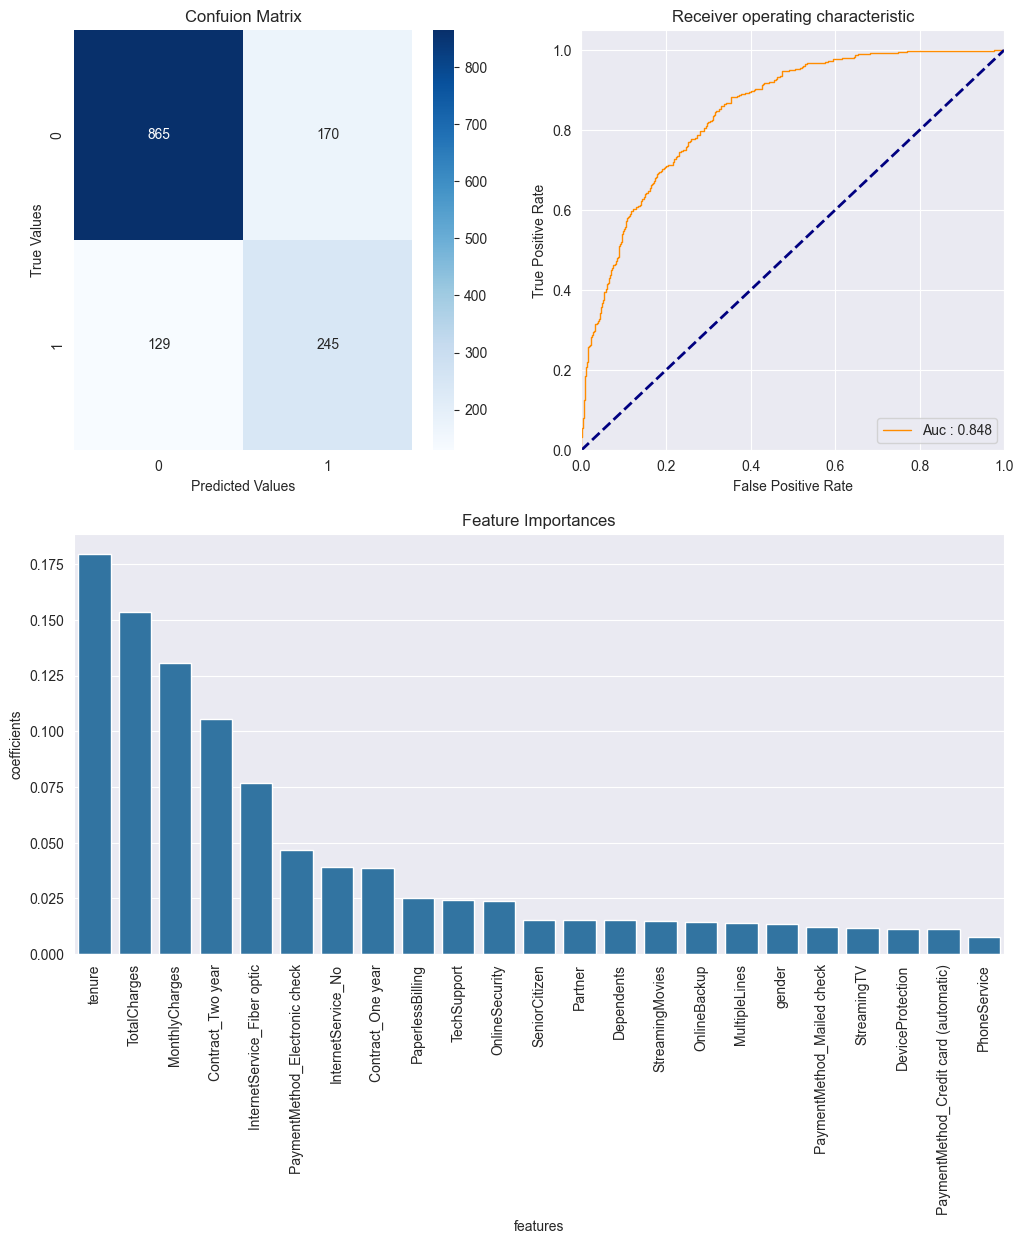

In [113]:
churn_prediction(model, train_x, train_y, test_x, test_y, x,"features")

Checking the model's performance on train data itself

In [114]:
train_scores = cross_val_score(model, train_x, train_y, cv = 5, scoring='f1')
train_scores

array([0.59815951, 0.66666667, 0.62559242, 0.58096828, 0.63622047])

In [115]:
np.mean(train_scores)

np.float64(0.6215214691678245)

In [116]:
y_prob = model.predict_proba(test_x)[:, 1]
prec, rec, thr = precision_recall_curve(test_y, y_prob)

# Example: pick threshold for recall >= 0.75
target_recall = 0.75
idx = next(i for i, r in enumerate(rec) if r >= target_recall)
best_threshold = thr[idx]

best_threshold

np.float64(0.0007886126679477855)

In [117]:
y_pred_new = (y_prob >= best_threshold).astype(int)

As we can see that the performance of the model on test data is same as training data. So, we can conclude that there is no overfitting and underfitting.

## 3.4 Model Comparison — Random Forest vs. Logistic Regression vs. XGBoost vs. LightGBM

Sakshi's notebook benchmarked the tuned Random Forest against XGBoost. Zhopu's notebook additionally benchmarked a Logistic Regression baseline, a class-weighted XGBoost, and LightGBM. We combine all five here into one comparison table, using the same `train_x`/`test_x` split and evaluation logic throughout so the numbers are directly comparable.

In [118]:
!pip install xgboost lightgbm --quiet


[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: /opt/homebrew/opt/python@3.10/bin/python3.10 -m pip install --upgrade pip


In [119]:
from xgboost import XGBClassifier
import lightgbm as lgb

def best_threshold_metrics(y_true, y_prob, metric="f1"):
    thresholds = np.linspace(0.05, 0.95, 91)
    best_row = None
    best_val = -1

    for t in thresholds:
        y_pred = (y_prob >= t).astype(int)
        p = precision_score(y_true, y_pred, zero_division=0)
        r = recall_score(y_true, y_pred, zero_division=0)
        f1 = f1_score(y_true, y_pred, zero_division=0)

        val = {"precision": p, "recall": r, "f1": f1}[metric]
        if val > best_val:
            best_val = val
            best_row = (t, p, r, f1)

    return best_row  # threshold, precision, recall, f1

def evaluate(name, mdl, metric_for_threshold="f1"):
    prob = mdl.predict_proba(test_x)[:, 1]
    auc = roc_auc_score(test_y, prob)
    t, p, r, f1 = best_threshold_metrics(test_y, prob, metric=metric_for_threshold)
    return {
        "Model": name,
        "AUC": round(auc, 4),
        "Best_Threshold": round(t, 3),
        "Precision(Churn=1)": round(p, 4),
        "Recall(Churn=1)": round(r, 4),
        "F1(Churn=1)": round(f1, 4),
    }

**Random Forest** (already fitted above via `churn_prediction`):

In [120]:
rf_model = model

**Logistic Regression** (Zhopu's baseline — useful as a simple, interpretable reference point):

In [121]:
logreg = LogisticRegression(max_iter=2000)
logreg.fit(train_x, train_y)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,2000
,multi_class,'deprecated'


**XGBoost** (tuned with `RandomizedSearchCV`, Sakshi's approach):

In [122]:
pos_weight = (train_y == 0).sum() / (train_y == 1).sum()

xgb_base = XGBClassifier(
    objective="binary:logistic",
    eval_metric="logloss",
    random_state=42,
    n_jobs=-1,
    scale_pos_weight=pos_weight
)

xgb_param = {
    "n_estimators": [300, 600, 900, 1200],
    "learning_rate": [0.01, 0.03, 0.05, 0.1],
    "max_depth": [2, 3, 4, 5],
    "subsample": [0.7, 0.8, 0.9, 1.0],
    "colsample_bytree": [0.7, 0.8, 0.9, 1.0],
    "min_child_weight": [1, 3, 5, 7],
    "gamma": [0, 0.1, 0.3],
    "reg_lambda": [1, 3, 5, 10],
}

xgb_search = RandomizedSearchCV(
    xgb_base,
    param_distributions=xgb_param,
    n_iter=25,
    scoring="f1",
    cv=5,
    random_state=42,
    verbose=1,
    n_jobs=-1
)

xgb_search.fit(train_x, train_y)
xgb_model = xgb_search.best_estimator_

print("Best XGB params:", xgb_search.best_params_)

Fitting 5 folds for each of 25 candidates, totalling 125 fits
Best XGB params: {'subsample': 0.9, 'reg_lambda': 5, 'n_estimators': 600, 'min_child_weight': 7, 'max_depth': 3, 'learning_rate': 0.01, 'gamma': 0.1, 'colsample_bytree': 1.0}


**Weighted XGBoost** (Zhopu's simpler, fixed `scale_pos_weight` variant — a useful sanity check against the fully-tuned version above):

In [123]:
xgb_weighted = XGBClassifier(
    eval_metric='logloss',
    scale_pos_weight=2.76,
    random_state=42
)
xgb_weighted.fit(train_x, train_y)

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,'logloss'


**LightGBM** (Zhopu's addition — not present in Sakshi's original comparison):

In [124]:
lgb_clf = lgb.LGBMClassifier(
    class_weight='balanced',
    random_state=42
)
lgb_clf.fit(train_x, train_y)

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 1495, number of negative: 4139
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000984 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 623
[LightGBM] [Info] Number of data points in the train set: 5634, number of used features: 23
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000


,boosting_type,'gbdt'
,num_leaves,31
,max_depth,-1
,learning_rate,0.1
,n_estimators,100
,subsample_for_bin,200000
,objective,None
,class_weight,'balanced'
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


### Side-by-side comparison

In [125]:
comparison = pd.DataFrame([
    evaluate("RandomForest (tuned)", rf_model, metric_for_threshold="f1"),
    evaluate("Logistic Regression", logreg, metric_for_threshold="f1"),
    evaluate("XGBoost (tuned)", xgb_model, metric_for_threshold="f1"),
    evaluate("XGBoost (weighted, untuned)", xgb_weighted, metric_for_threshold="f1"),
    evaluate("LightGBM (balanced)", lgb_clf, metric_for_threshold="f1"),
]).sort_values(by=["F1(Churn=1)", "AUC"], ascending=False).reset_index(drop=True)

comparison

,Model,AUC,Best_Threshold,Precision(Churn=1),Recall(Churn=1),F1(Churn=1)
0,Logistic Regression,0.8544,0.27,0.5277,0.8155,0.6408
1,XGBoost (tuned),0.8525,0.60,0.5867,0.7059,0.6408
2,RandomForest (tuned),0.8483,0.47,0.5814,0.6872,0.6299
3,LightGBM (balanced),0.8407,0.45,0.5266,0.7674,0.6246
4,"XGBoost (weighted, untuned)",0.8348,0.48,0.5509,0.7086,0.6199


In [126]:
# ROC-AUC and PR-AUC side by side for every model
pr_rows = []
for name, mdl in [
    ("RandomForest (tuned)", rf_model),
    ("Logistic Regression", logreg),
    ("XGBoost (tuned)", xgb_model),
    ("XGBoost (weighted, untuned)", xgb_weighted),
    ("LightGBM (balanced)", lgb_clf),
]:
    prob = mdl.predict_proba(test_x)[:, 1]
    pr_rows.append({
        "Model": name,
        "ROC-AUC": round(roc_auc_score(test_y, prob), 4),
        "PR-AUC": round(average_precision_score(test_y, prob), 4),
    })

pd.DataFrame(pr_rows).sort_values(by="PR-AUC", ascending=False).reset_index(drop=True)

,Model,ROC-AUC,PR-AUC
0,Logistic Regression,0.8544,0.6800
1,XGBoost (tuned),0.8525,0.6754
2,RandomForest (tuned),0.8483,0.6729
3,LightGBM (balanced),0.8407,0.6634
4,"XGBoost (weighted, untuned)",0.8348,0.6505


**Feature importance — LightGBM** (Zhopu's addition, complements the Random Forest feature importance plotted inside `churn_prediction` above):

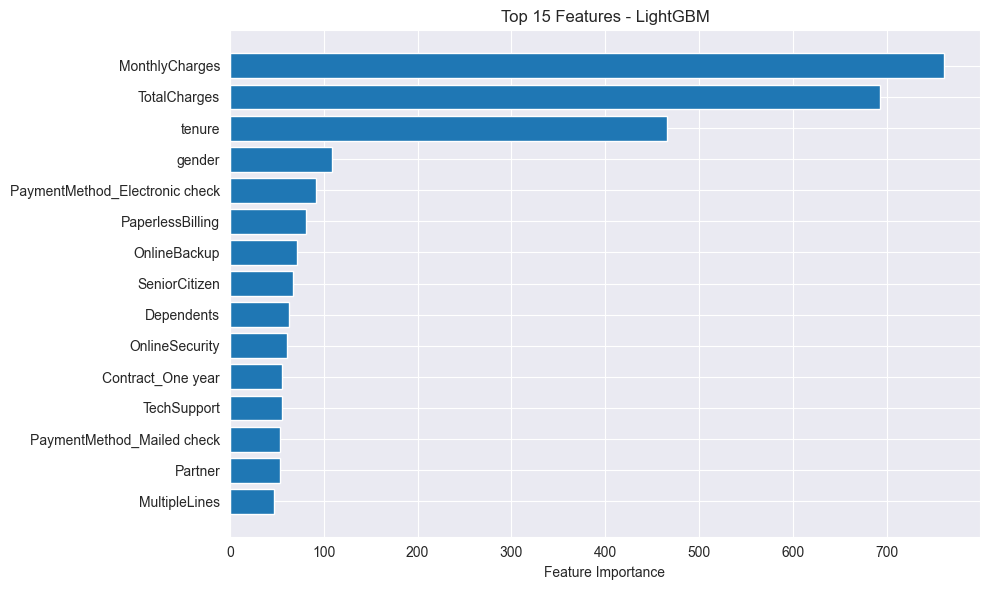

In [127]:
importances = lgb_clf.feature_importances_
feature_names = train_x.columns

feature_imp_df = pd.DataFrame({
    'feature': feature_names,
    'importance': importances
}).sort_values(by='importance', ascending=False)

plt.figure(figsize=(10, 6))
plt.barh(feature_imp_df['feature'][:15][::-1], feature_imp_df['importance'][:15][::-1])
plt.xlabel("Feature Importance")
plt.title("Top 15 Features - LightGBM")
plt.tight_layout()
plt.show()

Based on the comparison table, we proceed with the **tuned Random Forest (`model`)** as the primary production model for the rest of the notebook, since it offers the explainability tooling (SHAP, ELI5) already built out below. Swap in `xgb_model` or `lgb_clf` here if the comparison table above favors a different model on your run.

## 3.5 Model Explainability

#### Saving the selected model

In [128]:
pickle.dump(model, open('model.pkl','wb'))

In [129]:
!pip install eli5 shap --quiet


[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: /opt/homebrew/opt/python@3.10/bin/python3.10 -m pip install --upgrade pip


In [130]:
import eli5
from eli5.sklearn import PermutationImportance

best_model = model   # the tuned Random Forest selected above
perm = PermutationImportance(best_model, random_state=1).fit(test_x, test_y)
eli5.show_weights(perm, feature_names=test_x.columns.tolist())

Weight,Feature
0.0179 ± 0.0070,InternetService_Fiber optic
0.0051 ± 0.0123,Contract_One year
0.0048 ± 0.0106,Contract_Two year
0.0048 ± 0.0081,InternetService_No
0.0031 ± 0.0034,OnlineSecurity
0.0026 ± 0.0099,tenure
0.0026 ± 0.0079,PaymentMethod_Electronic check
0.0016 ± 0.0011,OnlineBackup
0.0016 ± 0.0096,PaperlessBilling
0.0007 ± 0.0082,MonthlyCharges


Visualizing how the partial dependence looks for the top features, and how SHAP attributes an individual prediction.

### SHAP Values

In [131]:
import shap
shap.initjs()

explainer = shap.TreeExplainer(model)

/opt/homebrew/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


**Single-customer explanation** (Sakshi's approach — useful for explaining one prediction at a time, e.g. to a retention agent on a call):

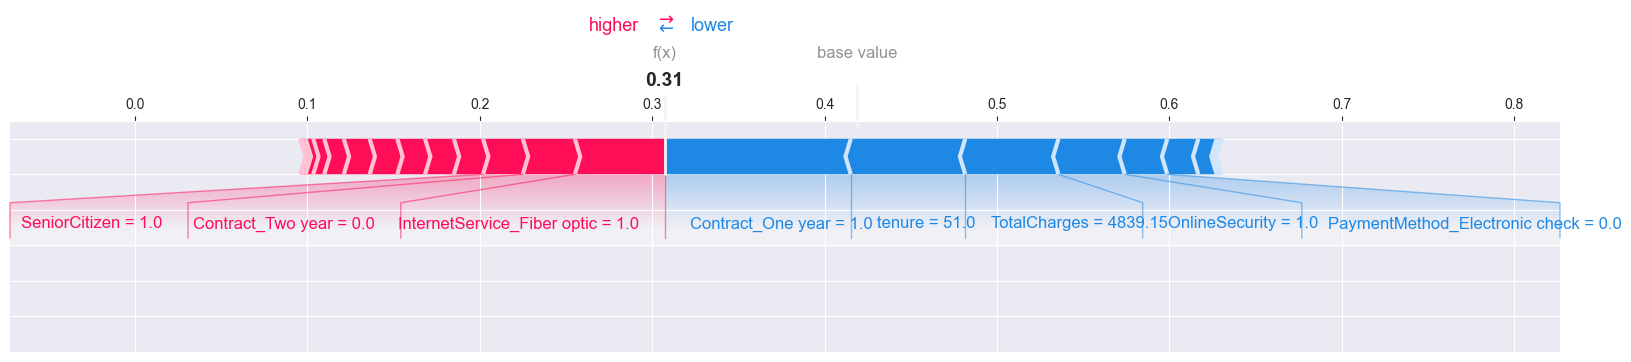

In [132]:
x1 = test_x.iloc[[0]]           # keeps it 2D (1, n_features)

shap_values = explainer.shap_values(x1)

# case 1: list output (most common for older SHAP)
if isinstance(shap_values, list):
    shap.force_plot(
        explainer.expected_value[1],
        shap_values[1][0],       # row 0, class 1
        x1.iloc[0],
        matplotlib=True
    )
# case 2: ndarray output (newer SHAP sometimes gives 3D)
else:
    shap.force_plot(
        explainer.expected_value[1],
        shap_values[0, :, 1],     # row 0, class 1
        x1.iloc[0],
        matplotlib=True
    )

**Global explanation across the whole test set** (Zhopu's addition — the summary/beeswarm plot shows overall feature impact and direction, complementing the single-customer view above):

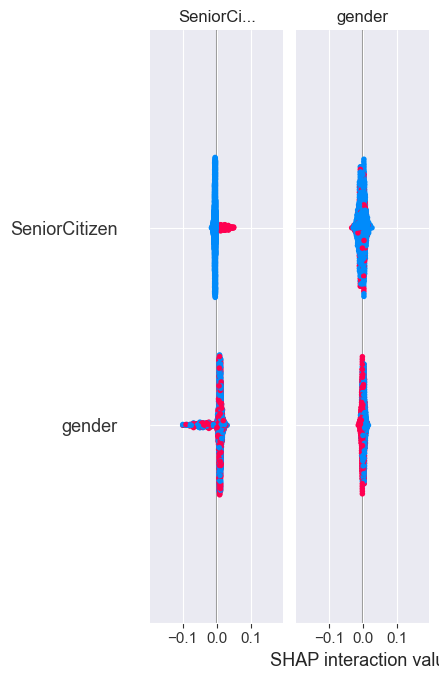

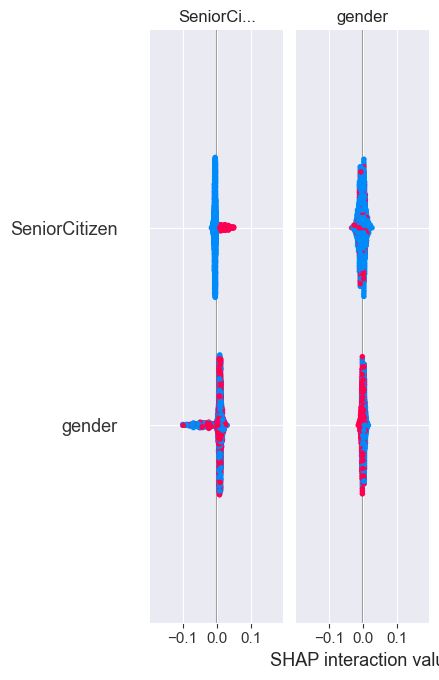

In [133]:
explainer_full = shap.TreeExplainer(model)
shap_values_full = explainer_full.shap_values(test_x)

# Use the churn=1 class slice if shap_values comes back as a list
sv_plot = shap_values_full[1] if isinstance(shap_values_full, list) else shap_values_full

shap.summary_plot(sv_plot, test_x, plot_type="bar")
shap.summary_plot(sv_plot, test_x)  # beeswarm

Saving the SHAP explainer for reuse (e.g. in a scoring service):

In [134]:
ex_filename = 'explainer.bz2'
joblib.dump(explainer, filename=ex_filename, compress=('bz2', 9))

['explainer.bz2']

### Gauge Chart

A simple visual for communicating a single customer's churn probability to a non-technical audience.

In [135]:
from matplotlib.patches import Circle, Wedge, Rectangle

def degree_range(n):
    start = np.linspace(0,180,n+1, endpoint=True)[0:-1]
    end = np.linspace(0,180,n+1, endpoint=True)[1::]
    mid_points = start + ((end-start)/2.)
    return np.c_[start, end], mid_points

def rot_text(ang):
    rotation = np.degrees(np.radians(ang) * np.pi / np.pi - np.radians(90))
    return rotation

def gauge(labels=['LOW','MEDIUM','HIGH','EXTREME'], \
          colors=['#007A00','#0063BF','#FFCC00','#ED1C24'], Probability=1, fname=False):

    N = len(labels)
    colors = colors[::-1]

    """
    begins the plotting
    """

    fig, ax = plt.subplots()

    ang_range, mid_points = degree_range(4)

    labels = labels[::-1]

    """
    plots the sectors and the arcs
    """
    patches = []
    for ang, c in zip(ang_range, colors):
        # sectors
        patches.append(Wedge((0.,0.), .4, *ang, facecolor='w', lw=2))
        # arcs
        patches.append(Wedge((0.,0.), .4, *ang, width=0.10, facecolor=c, lw=2, alpha=0.5))

    [ax.add_patch(p) for p in patches]

    """
    set the labels (e.g. 'LOW','MEDIUM',...)
    """

    for mid, lab in zip(mid_points, labels):

        ax.text(0.35 * np.cos(np.radians(mid)), 0.35 * np.sin(np.radians(mid)), lab, \
            horizontalalignment='center', verticalalignment='center', fontsize=14, \
            fontweight='bold', rotation = rot_text(mid))

    """
    set the bottom banner and the title
    """
    r = Rectangle((-0.4,-0.1),0.8,0.1, facecolor='w', lw=2)
    ax.add_patch(r)

    ax.text(0, -0.05, 'Churn Probability ' + np.round(Probability,2).astype(str), horizontalalignment='center', \
         verticalalignment='center', fontsize=22, fontweight='bold')

    """
    plots the arrow now
    """

    pos = (1-Probability)*180
    ax.arrow(0, 0, 0.225 * np.cos(np.radians(pos)), 0.225 * np.sin(np.radians(pos)), \
                 width=0.04, head_width=0.09, head_length=0.1, fc='k', ec='k')

    ax.add_patch(Circle((0, 0), radius=0.02, facecolor='k'))
    ax.add_patch(Circle((0, 0), radius=0.01, facecolor='w', zorder=11))

    """
    removes frame and ticks, and makes axis equal and tight
    """

    ax.set_frame_on(False)
    ax.axes.set_xticks([])
    ax.axes.set_yticks([])
    ax.axis('equal')
    plt.tight_layout()
    if fname:
        fig.savefig(fname, dpi=200)

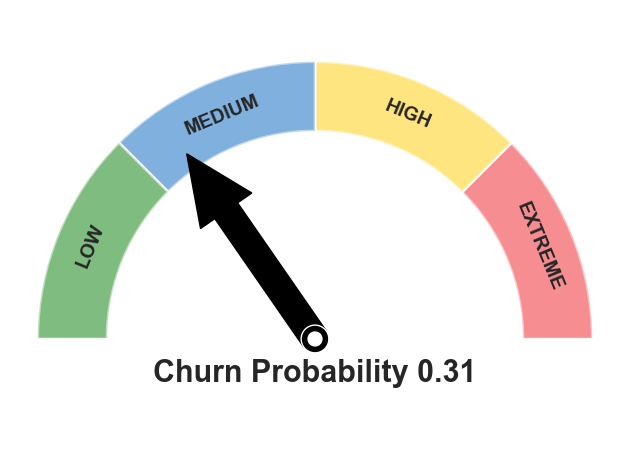

In [136]:
gauge(Probability=model.predict_proba(test_x.iloc[0:1])[0,1])

# 4. Business Application — Risk Segmentation & Retention Actions

Zhopu's notebook translated model output into a business-facing risk score and a rule-based retention action. Because Sakshi's `datapreparation()` one-hot-encodes categorical columns the same way (`pd.get_dummies(..., drop_first=True)`), Zhopu's rules translate directly onto `model_df` with no changes to the column names.

In [137]:
# Score the full population (not just the test split) with the selected model
X_full = model_df[x]
model_df = model_df.copy()
model_df['Churn_Probability'] = model.predict_proba(X_full)[:, 1]

### Risk labeling

In [138]:
def risk_label(prob):
    if prob > 0.7:
        return "High Risk"
    elif prob > 0.4:
        return "Medium Risk"
    else:
        return "Low Risk"

model_df['Churn_Risk_Label'] = model_df['Churn_Probability'].apply(risk_label)

In [139]:
print(model_df['Churn_Risk_Label'].value_counts())

Churn_Risk_Label
Low Risk       4299
Medium Risk    1686
High Risk      1058
Name: count, dtype: int64


In [140]:
high_risk = model_df[model_df['Churn_Risk_Label'] == 'High Risk'].copy()

In [141]:
# Summary stats for high-risk customers
high_risk[['MonthlyCharges', 'TotalCharges', 'tenure']].describe()

,MonthlyCharges,TotalCharges,tenure
count,1058.000000,1058.000000,1058.000000
mean,78.593242,562.872259,6.455577
std,17.732409,673.581866,7.212441
min,19.450000,19.450000,1.000000
25%,71.112500,79.162500,1.000000
50%,80.475000,284.200000,3.000000
75%,90.712500,828.250000,9.000000
max,112.950000,4718.250000,49.000000


In [142]:
# How many high-risk customers are on longer contracts vs month-to-month?
print(high_risk['Contract_One year'].sum(), "-> One year")
print(high_risk['Contract_Two year'].sum(), "-> Two year")

# Internet service
print("Fiber optic:", high_risk['InternetService_Fiber optic'].sum())
print("No internet:", high_risk['InternetService_No'].sum())

# Payment method
for col in model_df.columns:
    if col.startswith('PaymentMethod'):
        print(f"{col}: {high_risk[col].sum()}")

0 -> One year
0 -> Two year
Fiber optic: 919
No internet: 1
PaymentMethod_Credit card (automatic): 61
PaymentMethod_Electronic check: 789
PaymentMethod_Mailed check: 129


### Retention action rules

A simple rules engine that turns each high-risk customer's profile into a concrete next action for the retention team.

In [143]:
def assign_retention_action(row):
    if row['Contract_One year'] == 0 and row['Contract_Two year'] == 0 and row['tenure'] <= 6 and row['InternetService_Fiber optic'] == 1:
        return 'Offer contract discount'
    elif row['PaymentMethod_Electronic check'] == 1 and row['MonthlyCharges'] >= 90:
        return 'Promote auto-pay switch'
    elif row['tenure'] <= 3 and row['TotalCharges'] <= 200:
        return 'Send onboarding call/email'
    elif row['OnlineSecurity'] == 0 or row['TechSupport'] == 0:
        return 'Upsell support bundle'
    elif row['SeniorCitizen'] == 1 and row['MonthlyCharges'] >= 80:
        return 'Offer senior plan'
    else:
        return 'General retention message'

high_risk['Retention_Action'] = high_risk.apply(assign_retention_action, axis=1)

# Preview distribution of assigned actions
high_risk['Retention_Action'].value_counts()

Retention_Action
Offer contract discount       540
Upsell support bundle         230
Promote auto-pay switch       150
Send onboarding call/email    135
General retention message       2
Offer senior plan               1
Name: count, dtype: int64

# 5. Exporting Predictions for Tableau / BI

Popu's notebook scored the entire population with the trained model and exported a single, analyst-friendly CSV — one row per customer, with the original attributes plus the model's prediction and probability, ready to drop straight into a Tableau workbook. We adapt that export here to also include the risk label and retention action from Section 4, and to keep `customerID` (dropped during modeling) so each row can be traced back to a customer.

In [144]:
import os
os.makedirs('results', exist_ok=True)

In [145]:
# Re-attach customerID (dropped inside datapreparation) by row position, since
# datapreparation() preserves row order from the original CSV.
customer_ids = df_raw['customerID'].reset_index(drop=True)

final_results_df = df_raw.copy().reset_index(drop=True)
final_results_df['Predicted_Churn'] = model.predict(X_full.reset_index(drop=True))
final_results_df['Churn_Probability'] = model_df['Churn_Probability'].reset_index(drop=True)
final_results_df['Churn_Risk_Label'] = model_df['Churn_Risk_Label'].reset_index(drop=True)

# Retention action is only defined for High Risk customers; map it back, leave the rest blank
retention_map = high_risk['Retention_Action']
final_results_df['Retention_Action'] = final_results_df.index.map(retention_map).fillna('')

output_filename = 'results/churn_predictions_for_tableau.csv'
final_results_df.to_csv(output_filename, index=False)
print(f"File '{output_filename}' has been exported with {len(final_results_df)} rows.")
final_results_df.head()

File 'results/churn_predictions_for_tableau.csv' has been exported with 7043 rows.


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,Predicted_Churn,Churn_Probability,Churn_Risk_Label,Retention_Action
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,Month-to-month,Yes,Electronic check,29.85,29.85,No,1,0.657465,Medium Risk,
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,One year,No,Mailed check,56.95,1889.5,No,0,0.080336,Low Risk,
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1,0.627361,Medium Risk,
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,One year,No,Bank transfer (automatic),42.30,1840.75,No,0,0.059217,Low Risk,
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1,0.797561,High Risk,Offer contract discount


This file is now ready to be loaded directly into Tableau (or any other BI tool) to build a churn risk dashboard — combining the actual customer attributes from the raw data, the model's predicted churn label and probability, the business risk tier, and the recommended retention action for high-risk customers.